# RavenStack – Updating Reactive Customer Success Operations

Markdown and inline comments guide technical stakeholders through executing code. A complete summary outcomes is provided in the accompanying case study.

Execute the code in all cells in the order they appear below:

## Error handing

In [2]:
# Execute to supress memory leak warning using K-Means
import os
os.environ['OMP_NUM_THREADS'] = '8'

In [3]:
# Suppress warnings to maintain clean outputs
# Comment out as a first step to debug any problems encountered executing code in this notebook
import warnings
warnings.filterwarnings('ignore')

## Import libraries and packages

In [4]:
# Ensure nltk is available in the environment
!pip install nltk

In [5]:
# Data wrangling and numeric operations
import pandas as pd
import numpy as np

# Date manipulation
import datetime as dt

# Visualisation and plot styling
import seaborn as sns
import matplotlib.pyplot as plt

# Regex for text cleaning
import re

# Machine learning and modeling
import sklearn
from imblearn.over_sampling import SMOTE  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import silhouette_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler


# Statistical analysis
import scipy as scp
import scipy.stats as stats

# Natural Language Processing
import nltk
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
from collections import Counter

## Data ingestion

In [6]:
# Import accounts data
raccs = pd.read_csv('ravenstack_accounts.csv')

# Import subscription data
subs = pd.read_csv('ravenstack_subscriptions.csv')

# Import support ticket data
stix = pd.read_csv('ravenstack_support_tickets.csv')

# Import churn event data
chur = pd.read_csv('ravenstack_churn_events.csv')

# Import usage data
fuse = pd.read_csv('ravenstack_feature_usage.csv')

## Data validation and cleaning

### Validate and clean accounts data set

In [7]:
# Familiarisation - column and row counts
raccs.shape

(500, 10)

In [8]:
# Familiarisation - summary of df including datatypes, nulls
raccs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   account_id       500 non-null    object
 1   account_name     500 non-null    object
 2   industry         500 non-null    object
 3   country          500 non-null    object
 4   signup_date      500 non-null    object
 5   referral_source  500 non-null    object
 6   plan_tier        500 non-null    object
 7   seats            500 non-null    int64 
 8   is_trial         500 non-null    bool  
 9   churn_flag       500 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 32.4+ KB


In [9]:
# Familiarisation - column headings and first five rows
raccs.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [10]:
# Check for duplicate account_ids (should be none)
raccs[raccs.duplicated(subset=['account_id'], keep=False)]

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag


In [11]:
# Check for duplicate account_names - some companies may have multiple account_ids
raccs[raccs.duplicated(subset=['account_name'], keep=False)]

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag


In [12]:
# Use datetime to fix the signup_date column (currently object)
raccs['signup_date'] = pd.to_datetime(raccs['signup_date'])

In [13]:
# Inspect results
raccs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   account_name     500 non-null    object        
 2   industry         500 non-null    object        
 3   country          500 non-null    object        
 4   signup_date      500 non-null    datetime64[ns]
 5   referral_source  500 non-null    object        
 6   plan_tier        500 non-null    object        
 7   seats            500 non-null    int64         
 8   is_trial         500 non-null    bool          
 9   churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(1), object(6)
memory usage: 32.4+ KB


### Accounts observations and next actions

500 customers

 - No null values

 - No duplicates of account_id or account_name

 - Explore further to gain a picture of total recurring revenue, averages and largest/smallest customers etc

 - Churn indicated at account level. Likely need to compare with how churn is flagged at subscription level. Is this a total of all churn events?

### Validate and clean subscriptions data set

In [14]:
# Familiarisation - column and row counts
subs.shape

(5000, 14)

In [15]:
# Familiarisation - summary of df including datatypes, nulls
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_id    5000 non-null   object
 1   account_id         5000 non-null   object
 2   start_date         5000 non-null   object
 3   end_date           486 non-null    object
 4   plan_tier          5000 non-null   object
 5   seats              5000 non-null   int64 
 6   mrr_amount         5000 non-null   int64 
 7   arr_amount         5000 non-null   int64 
 8   is_trial           5000 non-null   bool  
 9   upgrade_flag       5000 non-null   bool  
 10  downgrade_flag     5000 non-null   bool  
 11  churn_flag         5000 non-null   bool  
 12  billing_frequency  5000 non-null   object
 13  auto_renew_flag    5000 non-null   bool  
dtypes: bool(5), int64(3), object(6)
memory usage: 376.1+ KB


In [16]:
# Familiarisation - column headings and first five rows
subs.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [17]:
# Check for duplicate subscription_ids (should be none)
subs[subs.duplicated(subset=['subscription_id'], keep=False)]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag


In [18]:
# Check for duplicate account_ids (subscription_id is the primary identifier here so likely to be many)
subs[subs.duplicated(subset=['account_id'], keep=False)]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S-c158df,A-fa2041,2024-10-27,NaN,Enterprise,18,3582,42984,False,False,False,False,monthly,True
4996,S-b49c0a,A-db5e9e,2024-12-05,NaN,Pro,23,1127,13524,False,False,False,False,monthly,False
4997,S-42822d,A-443f6f,2024-12-15,NaN,Pro,25,1225,14700,False,False,False,False,annual,True
4998,S-432401,A-c7ffc2,2023-05-25,NaN,Pro,132,6468,77616,False,False,False,False,monthly,True


In [19]:
# Use datetime to fix the date columns in subscriptions data set (currently object)
subs['start_date'] = pd.to_datetime(subs['start_date'])

subs['end_date'] = pd.to_datetime(subs['end_date'])

In [20]:
# Inspect results
subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   bool          
dtypes: bool(

### Subscriptions observations and next actions

 - 4514 active subscriptions

 - 486 terminated subscriptions 

 - No duplicates of subscription_id

 - Duplicates as expected in account_id column where a single account has multiple subscriptions

 - Merge with accounts data to calculate totals and explore quantitative and qualiatative data further to help identify next steps

 - Observations made about how churn is flagged at account and subscription level

 - Decision on inclusion of trial customers flagged with is_trial. Continue in further EDA in next section.

 - Explore billing frequency and auto renew flag for use in predictive and scoring models


### Validate and clean support tickets data set

In [21]:
# Familiarisation - column and row counts
stix.shape

(2000, 9)

In [22]:
# Familiarisation - summary of df including datatypes, nulls
stix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   object 
 1   account_id                   2000 non-null   object 
 2   submitted_at                 2000 non-null   object 
 3   closed_at                    2000 non-null   object 
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   object 
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 127.1+ KB


In [23]:
# Familiarisation - column headings and first five rows
stix.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [24]:
# Check for duplicate ticket_ids (should be none)
stix[stix.duplicated(subset=['ticket_id'], keep=False)]

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag


In [25]:
# Use datetime to fix the date columns (submitted_at and closed_at)
stix['submitted_at'] = pd.to_datetime(stix['submitted_at'])

stix['closed_at'] = pd.to_datetime(stix['closed_at'])

In [26]:
# Inspect results
stix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    2000 non-null   object        
 1   account_id                   2000 non-null   object        
 2   submitted_at                 2000 non-null   datetime64[ns]
 3   closed_at                    2000 non-null   datetime64[ns]
 4   resolution_time_hours        2000 non-null   float64       
 5   priority                     2000 non-null   object        
 6   first_response_time_minutes  2000 non-null   int64         
 7   satisfaction_score           1175 non-null   float64       
 8   escalation_flag              2000 non-null   bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 127.1+ KB


### Support tickets observations and next actions

2000 tickets, all closed (no nulls in closed_at column)

No duplicates in ticket_id column

Nulls in satisfaction_score where no response recieved from customer

Ticket data likely to provide features for churn prediction. That said, tickets are recorded at account level and other data sets are at a more granular subscription level.

Decisions to be made to resolve granularity challenges and identify the level at which to predict churn. Churn events are currently captured at both account and subscription level.

Impute mean score for that customer_id to replace nulls in health scoring workflow. If no accout mean is available, impute global mean.
Rationale: Customers return satisfaction surveys when they are extremely happy or when they are unhappy with aspects of product and service. I will assume that no response means they are adequately satisfied.

### Validate and clean churn event data set

In [27]:
# Familiarisation - column and row counts
chur.shape

(600, 9)

In [28]:
# Familiarisation - summary of df including datatypes, nulls
chur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    object 
 1   account_id                600 non-null    object 
 2   churn_date                600 non-null    object 
 3   reason_code               600 non-null    object 
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    object 
dtypes: bool(3), float64(1), object(5)
memory usage: 30.0+ KB


In [29]:
# Familiarisation - column headings and first five rows
chur.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [30]:
# Check for duplicate churn_event_ids
chur[chur.duplicated(subset=['churn_event_id'], keep=False)]

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text


In [31]:
# Use datetime to fix the churn_date column
chur['churn_date'] = pd.to_datetime(chur['churn_date'])

In [32]:
# Inspect results
chur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   churn_event_id            600 non-null    object        
 1   account_id                600 non-null    object        
 2   churn_date                600 non-null    datetime64[ns]
 3   reason_code               600 non-null    object        
 4   refund_amount_usd         600 non-null    float64       
 5   preceding_upgrade_flag    600 non-null    bool          
 6   preceding_downgrade_flag  600 non-null    bool          
 7   is_reactivation           600 non-null    bool          
 8   feedback_text             452 non-null    object        
dtypes: bool(3), datetime64[ns](1), float64(1), object(4)
memory usage: 30.0+ KB


### Churn Event observations

Churn Events cannot be used for predictive modelling since it is a record captured after the churn event has occured. There are no potential features that predict churn.

### Churn Event Deeper Dive

<Axes: xlabel='reason_code', ylabel='count'>

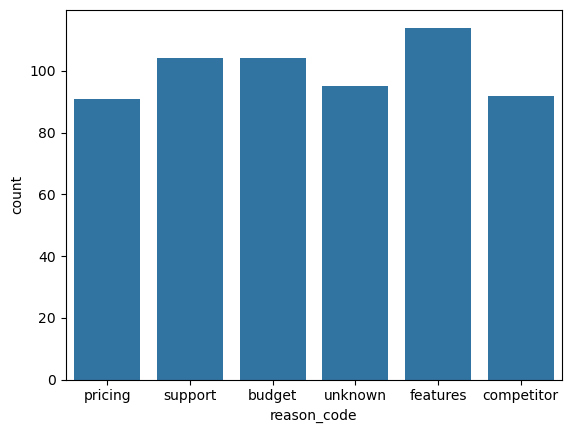

In [33]:
sns.countplot(x='reason_code', data=chur)

In [34]:
chur['reason_code'].value_counts()

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: count, dtype: int64

### Observation
Evidence of the synthetic nature of the data, the distribution of reasons codes for customer attrition is very evenly distributed.
There are almost as mnay 'unknown' as any other reason. There is very little that is actionable here and these insights should not be prioritised

With limited intel from historical churn, do not expect strong signals from the early iterations of a churn prediction model.

In [35]:
# Create a copy of churn events for natural laguage processing (NLP)
chur_nlp = chur.copy()

In [36]:
# Remove null values from 'feedback_text' column
chur_nlp['feedback_text'] = chur_nlp['feedback_text'].fillna('')

In [37]:
# Reset index after removing nulls
chur_nlp = chur_nlp.reset_index(drop=True)

In [38]:
# Calculate VADER compound sentiment scores
chur_nlp['feedback_sentiment'] = chur_nlp['feedback_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

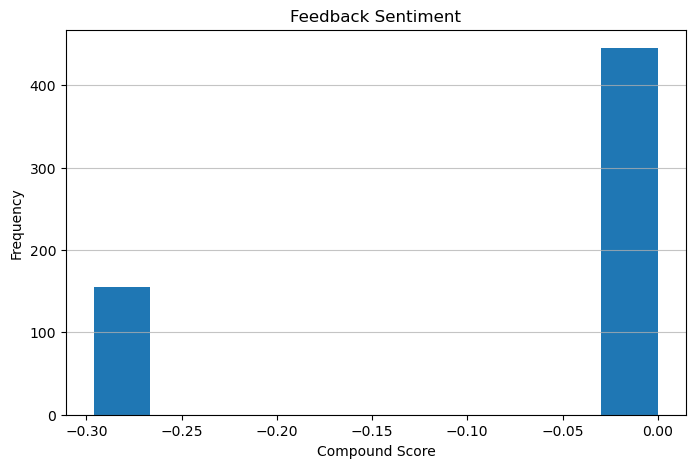

<Figure size 640x480 with 0 Axes>

In [39]:
# Histogram of compound sentiment scores

plt.figure(figsize=(8, 5))
plt.hist(chur_nlp['feedback_sentiment'])
plt.title('Feedback Sentiment')
plt.xlabel('Compound Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.savefig('feedback_senitment.png', dpi=300, bbox_inches='tight')

### Observations
Feedback is negative. Mostly 'slightly negative' ~450 between -0,05 and 0 and all the remaining reviews are at the extreme end of the scale between -0.3 and -0.25.

There is not sentiment data between these two extremes, which is another indication of the artificial nature of ths data set.

### Validate and clean feature usage data set

In [40]:
# Familiarisation - column and row counts
fuse.shape

(25000, 8)

In [41]:
# Familiarisation - summary of df including datatypes, nulls
fuse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   usage_id             25000 non-null  object
 1   subscription_id      25000 non-null  object
 2   usage_date           25000 non-null  object
 3   feature_name         25000 non-null  object
 4   usage_count          25000 non-null  int64 
 5   usage_duration_secs  25000 non-null  int64 
 6   error_count          25000 non-null  int64 
 7   is_beta_feature      25000 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 1.4+ MB


In [42]:
# Familiarisation - column headings and first five rows
fuse.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [43]:
# Check for duplicate usage_ids
fuse[fuse.duplicated(subset=['usage_id'], keep=False)]

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False
520,U-662254,S-3c072b,2023-10-24,feature_21,8,120,0,True
623,U-c878da,S-34f2f9,2024-03-27,feature_38,15,7170,0,False
644,U-f42b0a,S-02ec76,2023-05-05,feature_8,7,4158,0,False
768,U-8128da,S-6c969d,2024-05-27,feature_34,9,2520,0,False
1085,U-48a4aa,S-383ac2,2023-02-12,feature_28,14,7126,0,False
1213,U-7a87ed,S-3803ff,2024-04-05,feature_2,14,5516,0,False
1967,U-6970d1,S-3f0fb6,2023-12-15,feature_25,4,1168,0,False
4100,U-d20c6d,S-db56d2,2023-08-14,feature_14,8,1184,0,False
4167,U-8128da,S-9c85b0,2023-04-21,feature_24,13,806,1,False


In [44]:
# Inspect one duplicate usage_id from the list
fuse[fuse['usage_id'] == 'U-25b56c']

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False
7574,U-25b56c,S-34253c,2023-10-28,feature_20,6,2166,1,False


### Observation
Duplication of usage_id for different subscription_ids. Potential reliability issues in the data.
For analytical purposes, recreate usage_ids using index so that they are unique.
IRL escalate problem where usage_id is duplicated across different subscription_ids

In [45]:
# Use datetime to fix the usage_date column dtype
fuse['usage_date'] = pd.to_datetime(fuse['usage_date'])

In [46]:
# Drop original usage_id which contains duplicates
# Reset index, create new usage_id with dtype of integer 
fuse = fuse.drop('usage_id', axis=1).reset_index(drop=True)
fuse['usage_id'] = fuse.index

In [47]:
# Reorder columns so usage_id is first from left
cols = ['usage_id'] + [col for col in fuse.columns if col != 'usage_id']
fuse = fuse[cols]

In [48]:
# Inspect results of previous two cleaning measures
fuse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   usage_id             25000 non-null  int64         
 1   subscription_id      25000 non-null  object        
 2   usage_date           25000 non-null  datetime64[ns]
 3   feature_name         25000 non-null  object        
 4   usage_count          25000 non-null  int64         
 5   usage_duration_secs  25000 non-null  int64         
 6   error_count          25000 non-null  int64         
 7   is_beta_feature      25000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(4), object(2)
memory usage: 1.4+ MB


In [49]:
# Check for duplicate usage_ids in column rebuilt from index (there will be none but check!)
fuse[fuse.duplicated(subset=['usage_id'], keep=False)]

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature


### Feature usage observations and next steps

 - Noted a reliability issue with duplicate usage_id with different subscription_ids. I rebuilt the usage_id column and further analysis would need to assume that the subscription_id recorded in each row is correct.
   
 - Feature usage has potential for churn prediction model. Note previous observations about account and subscription level data since feature usage is captured at the more granular subscription level.

 - Also, uncertainty about the record of the correct subscription id poses problems for using feature usage in predictive modelling

## Revenue EDA

Merge subscriptions and accounts to calculate revenue totals and explore categorical data further

In [50]:
# Check column names for potential duplicates
print(subs.columns)
print(raccs.columns)

Index(['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier',
       'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag',
       'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag'],
      dtype='object')
Index(['account_id', 'account_name', 'industry', 'country', 'signup_date',
       'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag'],
      dtype='object')


In [51]:
# Make copy of raccs with just the required columns to prepare for merge
raccs_clean = raccs[['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source']].copy()

# Merge subscriptions and accounts
subs_accounts = subs.merge(raccs_clean, on='account_id', how='left')

In [52]:
# Familiarisation - column and row counts
subs_accounts.shape

(5000, 19)

In [53]:
# Familiarisation - summary of df including datatypes, nulls
subs_accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   object        
 1   account_id         5000 non-null   object        
 2   start_date         5000 non-null   datetime64[ns]
 3   end_date           486 non-null    datetime64[ns]
 4   plan_tier          5000 non-null   object        
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   object        
 13  auto_renew_flag    5000 non-null   bool          
 14  account_

In [54]:
# Find accounts with multiple subscriptions
multi_subs = subs_accounts[subs_accounts.duplicated(subset=['account_id'], keep=False)]

In [55]:
# Pick one account_id and inspect
sample_account = multi_subs['account_id'].iloc[0]
subs_accounts[subs_accounts['account_id'] == sample_account]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,Company_224,DevTools,UK,2023-08-26,event
104,S-2214c6,A-3c1a3f,2024-10-07,NaT,Pro,82,4018,48216,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
701,S-a10eb2,A-3c1a3f,2023-08-31,NaT,Basic,45,0,0,True,False,False,False,annual,False,Company_224,DevTools,UK,2023-08-26,event
1213,S-e9737c,A-3c1a3f,2023-12-28,NaT,Enterprise,29,5771,69252,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
1651,S-e6b35a,A-3c1a3f,2024-03-25,NaT,Basic,4,76,912,False,False,False,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
2824,S-a99771,A-3c1a3f,2023-12-18,NaT,Basic,25,0,0,True,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3014,S-511e50,A-3c1a3f,2024-10-13,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3144,S-4ad7b1,A-3c1a3f,2024-04-28,NaT,Enterprise,2,398,4776,False,False,True,False,monthly,True,Company_224,DevTools,UK,2023-08-26,event
3239,S-715ace,A-3c1a3f,2023-12-29,NaT,Pro,1,0,0,True,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3826,S-5856ab,A-3c1a3f,2024-05-06,2024-11-25,Pro,19,931,11172,False,False,False,True,annual,True,Company_224,DevTools,UK,2023-08-26,event


### Account-Subscription Complexity Observations

- One account can have multiple subscriptions (example: account_id A-3c1a3f has 12 subscriptions)
- Subscriptions can overlap in time (active and churned subscriptions coexisting)
- Plans vary across subscriptions for the same account (Basic, Pro, Enterprise)
- Zero-dollar subscriptions (trials) appear alongside paid subscriptions
- Churned subscriptions exist on accounts that remain active overall

### Observations and next steps from this analysis

- Ignore zero-dollar (trial) subscriptions in revenue calculations and predictive model
- Potential upsell/consolidation opportunities where customers have subscriptions in different plan tiers

### Revenue exploration
Use ARR not MRR due to volatility in churning subscriptions.
ARR is a snap shot of annualised revenue from active subscriptions right now.

In [56]:
# Subset paid subscriptions and create independent copy for reuse
paid_customers = subs_accounts[subs_accounts['is_trial'] == False].copy()

In [57]:
# Identify rows with maximum ARR for active subscriptions
# Who is our biggest customer?
paid_customers[paid_customers['arr_amount'] == paid_customers['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2245,S-78f738,A-c70870,2024-12-29,NaT,Enterprise,170,33830,405960,False,False,True,False,monthly,True,Company_253,Cybersecurity,US,2024-10-22,partner


In [58]:
# Calculate paid ARR of active subscriptions
print(paid_customers['arr_amount'].mean())

32227.608716248225


In [59]:
# Calculate total ARR of paid subscriptions
print(paid_customers['arr_amount'].sum())

136064964


In [60]:
# Make sure no revenue booked against trial subscriptions
trial_customers = subs_accounts[subs_accounts['is_trial'] == True].copy()

In [61]:
# Calculate total ARR of trial subscriptions (should be zero)
print(trial_customers['arr_amount'].sum())

0


### Lost revenue
Explore cost of churn

In [62]:
# Subset inactive subscriptions to analyse churned revenue
churned_subs = subs_accounts[subs_accounts['churn_flag'] == True].copy()

In [63]:
# Establish number of churned subscriptions
churned_subs.shape

(486, 19)

In [64]:
# Calculate total ARR of inactive subscriptions
print(churned_subs['arr_amount'].sum())

14149668


In [65]:
# Active subscription was 121915296 ARR. Obtain active/inactive ARR total to make sure the numbers add uo
print(subs_accounts['arr_amount'].sum())

136064964


In [66]:
#Establish date range of activity to calculate annualised churn (min start date)
print(subs_accounts['start_date'].min())

2023-01-09 00:00:00


In [67]:
#Establish date range of activity to calculate annualised churn (max end date)
print(subs_accounts['end_date'].max())

2024-12-31 00:00:00


### Lost revenue summary

136064964 - 14149668 = 121915296

During two years (Jan 2023 - Dec 2024) churn ARR = approximately 10%

In case study, describe 5% Annualised churn

### Plan tier observation 1
The plan tiers look remarkably even. Remove trial subscriptions to see how much noise they create

<Axes: xlabel='plan_tier', ylabel='count'>

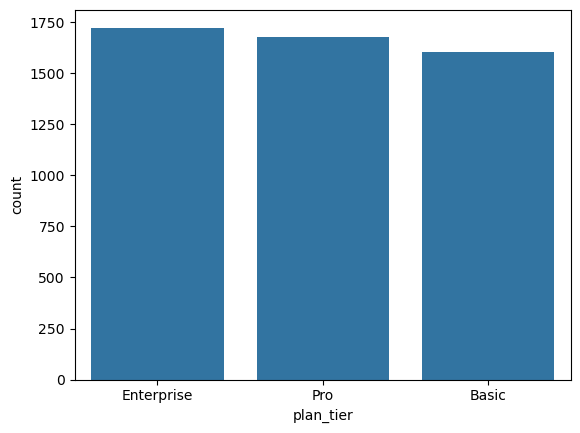

In [68]:
# Check distribution of tiers for all subscriptions
sns.countplot(x='plan_tier', data=subs_accounts)

<Axes: xlabel='plan_tier', ylabel='count'>

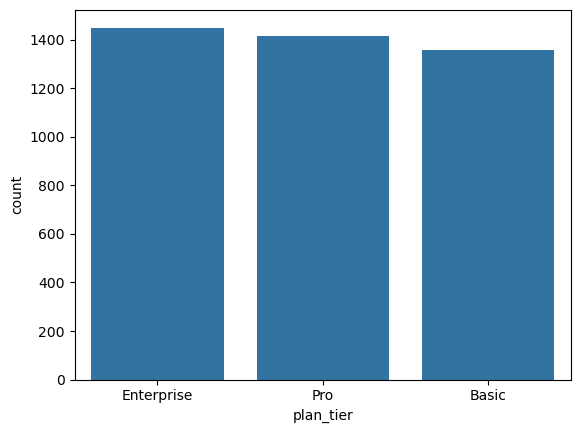

In [69]:
# Compare with plan distribution for non-trial subscriptions
sns.countplot(x='plan_tier', data=paid_customers)

### Plan tier observation 2
The without trial subscriptions,  plan tiers still look remarkably even. This is not a blocker, rather one of many indications of the synthetic nature of the data.
Continue to explore revenue statistics for each one.

In [70]:
# Subset non trial Enterprise subscriptions for analysis
paid_ent = paid_customers[paid_customers['plan_tier'] == 'Enterprise'].copy()

In [71]:
# Validate df by checking that the account with highest arr_amount within matches the 'biggest customer' globally
# Should match with result from row 61, above (account_if A-c70870)
paid_ent[paid_ent['arr_amount'] == paid_ent['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2245,S-78f738,A-c70870,2024-12-29,NaT,Enterprise,170,33830,405960,False,False,True,False,monthly,True,Company_253,Cybersecurity,US,2024-10-22,partner


In [72]:
# With trials filtered out, check minimum ARR subscriptions in every plan tier
# Start with Enterprise
paid_ent[paid_ent['arr_amount'] == paid_ent['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
261,S-cb8a5c,A-1e6fc3,2024-12-17,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_434,EdTech,FR,2023-12-06,other
1561,S-8fd22d,A-354f12,2024-08-01,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,True,Company_201,FinTech,US,2024-04-28,ads
1626,S-fc155b,A-ccabf0,2024-09-09,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_471,HealthTech,IN,2023-11-06,organic
2454,S-ea3d54,A-439b2f,2024-05-30,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,False,Company_152,DevTools,US,2024-02-21,ads
3014,S-511e50,A-3c1a3f,2024-10-13,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_224,DevTools,UK,2023-08-26,event
3195,S-36069b,A-940b8b,2024-06-26,NaT,Enterprise,1,199,2388,False,False,False,False,annual,True,Company_398,HealthTech,DE,2024-03-19,organic
4239,S-0b8b0c,A-f17767,2024-08-03,NaT,Enterprise,1,199,2388,False,False,False,False,monthly,False,Company_123,DevTools,US,2023-01-30,event


### Enterprise plan observations

This is sufficient to proceed with k-means clustering to seek out disctinct segments. Currently, plan_tier is the only ordinal/categorical data to size customers. Another method is to report on revenue metrics and seats owned. Clustering would group accounts along categorical and revenue lines resulting in targeted initiatives, resource allocation and prioritisation.

Check other plan tiers before proceeding on to clustering EDA.

In [73]:
# Subset non trial Pro subscriptions for analysis
paid_pro = paid_customers[paid_customers['plan_tier'] == 'Pro'].copy()

In [74]:
# Identify rows with maximum ARR for active subscriptions for paying Pro tier subscriptions
# Compare with Enterprise revenues for further validation of the observations about a process gap in segmentation
paid_pro[paid_pro['arr_amount'] == paid_pro['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
2353,S-e11518,A-3ce5b8,2023-12-15,NaT,Pro,189,9261,111132,False,False,False,False,annual,True,Company_256,FinTech,IN,2023-09-07,ads


In [75]:
# Observe minimum ARR subscriptions for Pro plan tier
paid_pro[paid_pro['arr_amount'] == paid_pro['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
94,S-367dee,A-e19ff6,2024-06-29,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_411,Cybersecurity,UK,2023-07-28,partner
216,S-aa20eb,A-6f8ad2,2024-09-08,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_57,EdTech,IN,2024-07-09,organic
2742,S-0f7a92,A-700ade,2024-12-23,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_472,Cybersecurity,UK,2024-10-31,organic
2869,S-c52d77,A-6e7827,2023-11-05,NaT,Pro,1,49,588,False,True,False,False,monthly,False,Company_372,DevTools,US,2023-03-26,other
2919,S-09c1df,A-b7724f,2024-09-15,2024-10-02,Pro,1,49,588,False,False,False,True,annual,True,Company_320,HealthTech,UK,2023-03-28,organic
2961,S-1261fb,A-fd7ad3,2024-11-29,NaT,Pro,1,49,588,False,False,False,False,monthly,False,Company_100,Cybersecurity,US,2024-11-01,event
2962,S-561d54,A-0a282f,2024-11-10,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_2,DevTools,US,2024-08-27,organic
3036,S-06447b,A-17939a,2024-12-27,NaT,Pro,1,49,588,False,False,False,False,annual,True,Company_162,HealthTech,US,2024-12-26,organic
3604,S-b120fb,A-f51f16,2024-04-01,2024-08-23,Pro,1,49,588,False,False,False,True,annual,False,Company_282,HealthTech,US,2023-12-25,partner
4123,S-2881e0,A-42e5e1,2024-07-21,NaT,Pro,1,49,588,False,False,True,False,annual,True,Company_118,DevTools,US,2024-07-09,ads


### Pro plan observations

Further justifcation for segmentation and upsell recommendations

 - Largest Pro plan subscription paying Enterprise subscription fees (> $100k)

 - Many with 1 seat and paying $588 ARR

In [76]:
# Subset non trial Pro subscriptions for analysis
paid_basic = paid_customers[paid_customers['plan_tier'] == 'Basic'].copy()

In [77]:
# Identify rows with maximum ARR for active Basic subscriptions
# Compare with Enterprise & Pro revenues
paid_basic[paid_basic['arr_amount'] == paid_basic['arr_amount'].max()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
710,S-c8fa77,A-56962b,2024-08-28,NaT,Basic,163,3097,37164,False,False,False,False,monthly,True,Company_177,EdTech,UK,2024-04-09,partner
3002,S-4970c1,A-56962b,2024-09-03,NaT,Basic,163,3097,37164,False,False,False,False,annual,True,Company_177,EdTech,UK,2024-04-09,partner


In [78]:
# Observe minimum ARR subscriptions for Basic plan tier
paid_basic[paid_basic['arr_amount'] == paid_basic['arr_amount'].min()]

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
1604,S-4047a8,A-e19ff6,2024-06-01,NaT,Basic,1,19,228,False,False,False,False,monthly,False,Company_411,Cybersecurity,UK,2023-07-28,partner
1996,S-d19797,A-fd7ad3,2024-11-10,NaT,Basic,1,19,228,False,False,False,False,monthly,True,Company_100,Cybersecurity,US,2024-11-01,event
2007,S-c2b60b,A-5a184f,2024-10-20,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_124,DevTools,DE,2023-06-19,other
2513,S-ccf9c8,A-956988,2024-12-14,NaT,Basic,1,19,228,False,False,False,False,monthly,False,Company_14,EdTech,UK,2024-11-30,ads
3673,S-8d4b81,A-2b9d3e,2024-04-28,NaT,Basic,1,19,228,False,False,False,False,annual,False,Company_319,EdTech,US,2023-06-04,partner
3728,S-e77d56,A-9289f6,2023-12-06,NaT,Basic,1,19,228,False,False,False,False,monthly,True,Company_104,EdTech,US,2023-05-31,event
3839,S-860bc8,A-42e5e1,2024-08-29,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_118,DevTools,US,2024-07-09,ads
4641,S-bbc0f7,A-b7724f,2024-09-15,NaT,Basic,1,19,228,False,False,False,False,annual,True,Company_320,HealthTech,UK,2023-03-28,organic


### Basic plan observations
Nothing added from evaluation of Enterprise and Pro plans 

## Segmentation

### Segmentation EDA
Identify features for clustering using K-means. use 'paid_customers' as a starting point since churned subscriptions are filtered out.

In [79]:
paid_customers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4222 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    4222 non-null   object        
 1   account_id         4222 non-null   object        
 2   start_date         4222 non-null   datetime64[ns]
 3   end_date           408 non-null    datetime64[ns]
 4   plan_tier          4222 non-null   object        
 5   seats              4222 non-null   int64         
 6   mrr_amount         4222 non-null   int64         
 7   arr_amount         4222 non-null   int64         
 8   is_trial           4222 non-null   bool          
 9   upgrade_flag       4222 non-null   bool          
 10  downgrade_flag     4222 non-null   bool          
 11  churn_flag         4222 non-null   bool          
 12  billing_frequency  4222 non-null   object        
 13  auto_renew_flag    4222 non-null   bool          
 14  account_name 

In [80]:
# Aggegate arr and seat counts, grouping by account_id for account totals
account_totals = paid_customers.groupby('account_id').agg(
    total_arr=('arr_amount', 'sum'),
    total_seats=('seats', 'sum')
).reset_index()

In [81]:
account_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   500 non-null    object
 1   total_arr    500 non-null    int64 
 2   total_seats  500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


In [82]:
account_totals = account_totals.merge(raccs, on='account_id', how='left')

In [83]:
account_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   total_arr        500 non-null    int64         
 2   total_seats      500 non-null    int64         
 3   account_name     500 non-null    object        
 4   industry         500 non-null    object        
 5   country          500 non-null    object        
 6   signup_date      500 non-null    datetime64[ns]
 7   referral_source  500 non-null    object        
 8   plan_tier        500 non-null    object        
 9   seats            500 non-null    int64         
 10  is_trial         500 non-null    bool          
 11  churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(3), object(6)
memory usage: 40.2+ KB


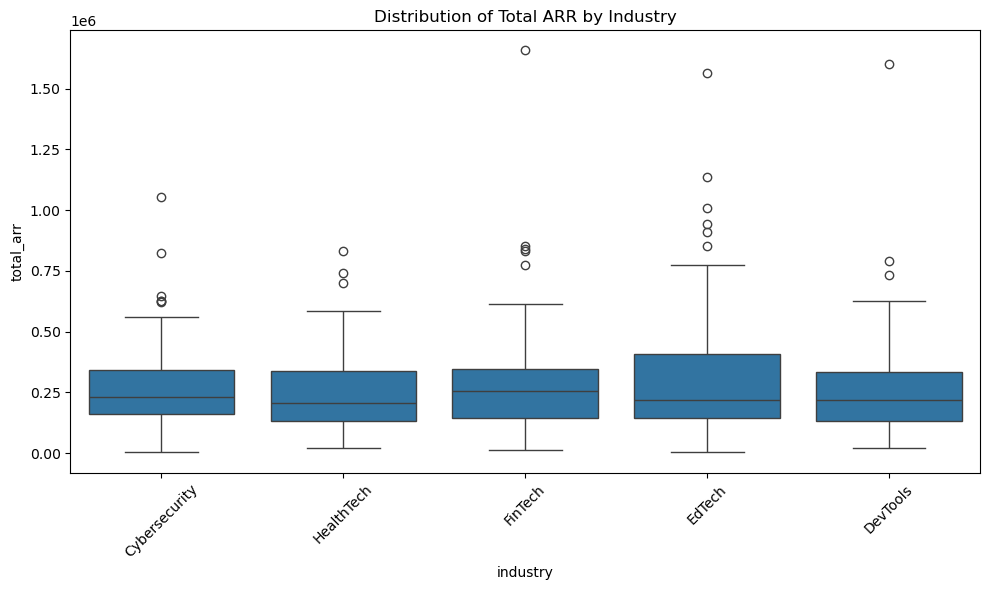

<Figure size 640x480 with 0 Axes>

In [84]:
# Boxplot to identify revenue/industry groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='industry', y='total_arr')
plt.xticks(rotation=45)
plt.title('Distribution of Total ARR by Industry')
plt.tight_layout()
plt.show()

plt.savefig('industry_arr_box.png', dpi=300, bbox_inches='tight')

In [85]:
# Obtain statistics to accompany above visual
industry_arr_stats = account_totals.groupby('industry')['total_arr'].describe()
print(industry_arr_stats)

               count           mean            std      min       25%  \
industry                                                                
Cybersecurity  100.0  270398.160000  170466.028687   2280.0  162321.0   
DevTools       113.0  255255.292035  198284.201237  21552.0  133044.0   
EdTech          79.0  310354.481013  281222.617975   5328.0  143148.0   
FinTech        112.0  286017.428571  217622.175093  14136.0  144378.0   
HealthTech      96.0  246139.000000  163923.743192  18720.0  130512.0   

                    50%       75%        max  
industry                                      
Cybersecurity  231774.0  339711.0  1055484.0  
DevTools       217584.0  333180.0  1599576.0  
EdTech         219780.0  407988.0  1561824.0  
FinTech        253584.0  344235.0  1656720.0  
HealthTech     204924.0  339183.0   830208.0  


### Observations on potential clusters by industry + arr
 - Standard deviations are large

 - Means and medians are close across industries

 - Industry + arr shows wide internal variation and overlapping distributions, suggesting little value for segmentation

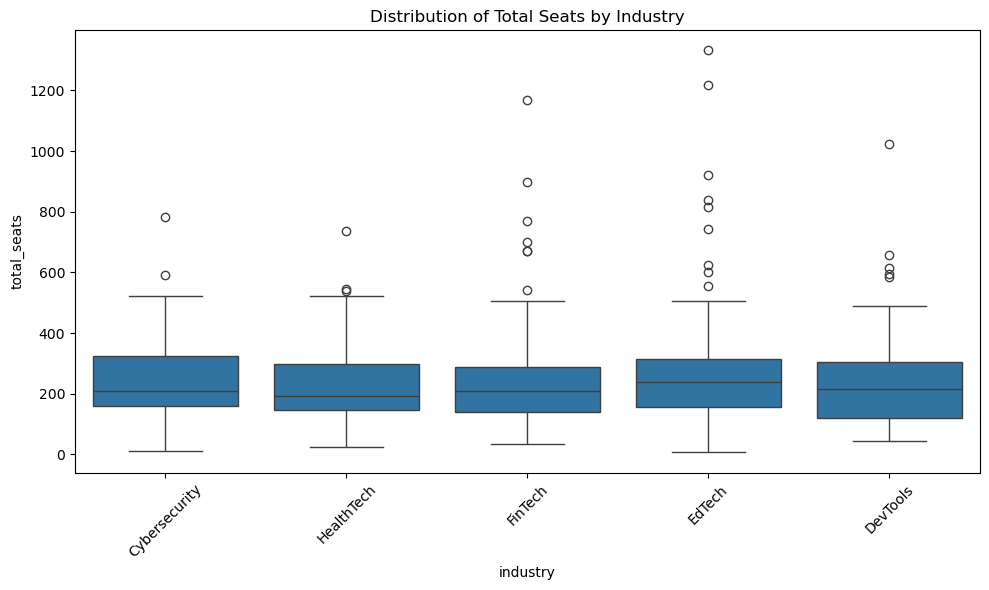

<Figure size 640x480 with 0 Axes>

In [86]:
# Boxplot to identify seat/industry groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='industry', y='total_seats')
plt.xticks(rotation=45)
plt.title('Distribution of Total Seats by Industry')
plt.tight_layout()
plt.show()

plt.savefig('industry_seats_box.png', dpi=300, bbox_inches='tight')

In [87]:
# Obtain statistics to accompany above visual
industry_seats_stats = account_totals.groupby('industry')['total_seats'].describe()
print(industry_seats_stats)

               count        mean         std   min     25%    50%     75%  \
industry                                                                    
Cybersecurity  100.0  248.220000  128.606092  10.0  157.75  207.5  323.75   
DevTools       113.0  236.601770  149.382690  44.0  120.00  215.0  303.00   
EdTech          79.0  290.037975  243.196262   6.0  157.50  237.0  315.00   
FinTech        112.0  257.357143  179.202933  34.0  140.75  209.5  287.25   
HealthTech      96.0  231.958333  128.851274  25.0  144.75  191.0  296.50   

                  max  
industry               
Cybersecurity   783.0  
DevTools       1022.0  
EdTech         1332.0  
FinTech        1170.0  
HealthTech      736.0  


### Observations on potential clusters by industry + seats
 - Standard deviations are large

 - Means and medians are close across industries

 - Industry + seats shows similar results as Industry + arr. Continue to explore feature combinations for segmentation

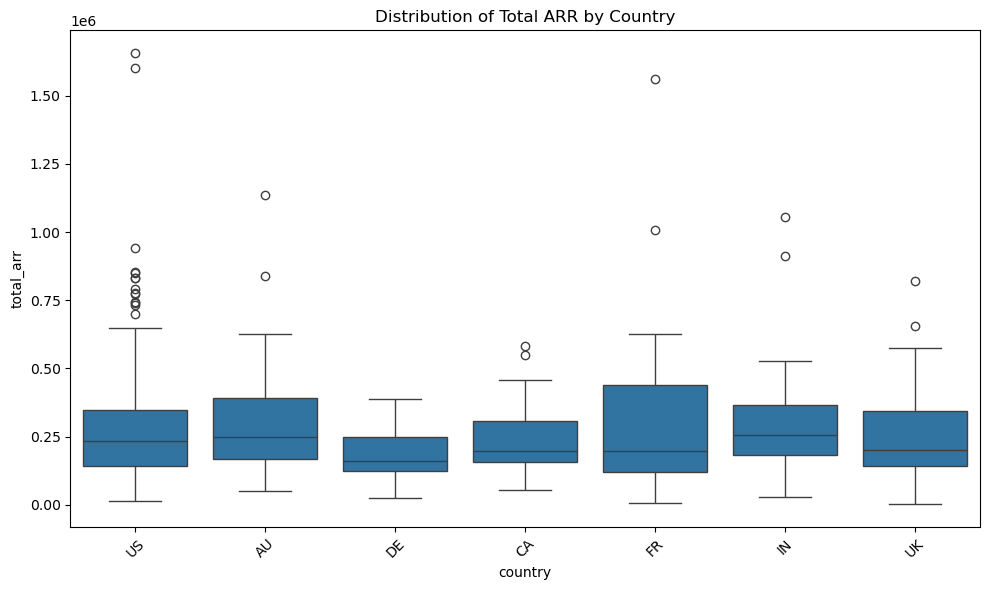

<Figure size 640x480 with 0 Axes>

In [88]:
# Boxplot to identify revenue/country groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='country', y='total_arr')
plt.xticks(rotation=45)
plt.title('Distribution of Total ARR by Country')
plt.tight_layout()
plt.show()

plt.savefig('country_arr_box.png', dpi=300, bbox_inches='tight')

In [89]:
# Obtain statistics to accompany above visual
country_arr_stats = account_totals.groupby('country')['total_arr'].describe()
print(country_arr_stats)

         count           mean            std      min       25%       50%  \
country                                                                     
AU        32.0  314992.500000  233443.228651  50328.0  167118.0  249768.0   
CA        23.0  249162.782609  142121.354539  53364.0  155670.0  198240.0   
DE        25.0  183368.640000  100748.259013  23868.0  124344.0  159540.0   
FR        22.0  321706.909091  366447.108205   5328.0  118977.0  197232.0   
IN        49.0  292487.755102  189645.567602  27912.0  181932.0  257400.0   
UK        58.0  252511.241379  174341.218910   2280.0  141675.0  200928.0   
US       291.0  273591.546392  207377.981826  14136.0  142014.0  232548.0   

              75%        max  
country                       
AU       390177.0  1136520.0  
CA       307194.0   583764.0  
DE       248196.0   389724.0  
FR       438063.0  1561824.0  
IN       366288.0  1055484.0  
UK       342990.0   821868.0  
US       347988.0  1656720.0  


### Observations on potential clusters by country + arr
 - Standard deviations are large

 - More variation than compared with industry + arr

 - Distributions overlap - not distinct enough grouping for kmeans

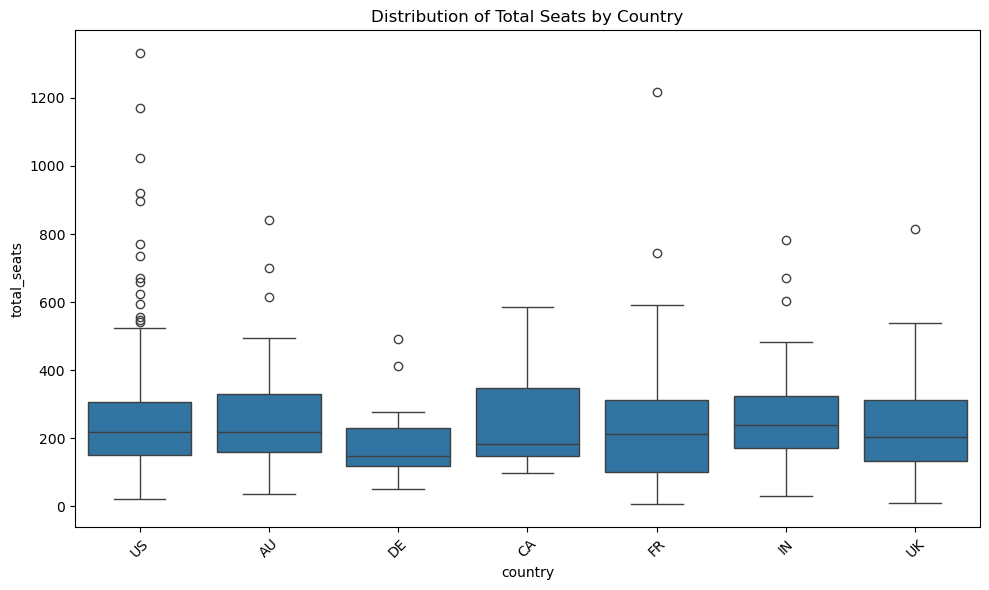

<Figure size 640x480 with 0 Axes>

In [90]:
# Boxplot to identify seat/country groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='country', y='total_seats')
plt.xticks(rotation=45)
plt.title('Distribution of Total Seats by Country')
plt.tight_layout()
plt.show()

plt.savefig('countryy_seats_box.png', dpi=300, bbox_inches='tight')

In [91]:
# Obtain statistics to accompany above visual
country_seats_stats = account_totals.groupby('country')['total_seats'].describe()
print(country_seats_stats)

         count        mean         std   min     25%    50%     75%     max
country                                                                    
AU        32.0  278.750000  181.268292  36.0  160.00  219.5  331.00   840.0
CA        23.0  250.347826  141.583451  98.0  148.50  182.0  348.50   586.0
DE        25.0  180.880000   99.146911  51.0  119.00  148.0  230.00   491.0
FR        22.0  282.909091  278.356898   6.0   99.75  213.5  312.75  1218.0
IN        49.0  261.938776  148.638881  29.0  170.00  238.0  323.00   783.0
UK        58.0  243.086207  149.723287  10.0  132.50  202.5  312.75   815.0
US       291.0  251.563574  168.515686  21.0  151.50  217.0  306.50  1332.0


### Observations on potential clusters by country + seats

 - Similar to country + arr

 - Variation exists but distributions overlap too heavily

In [92]:
account_totals['referral_source'].unique()

array(['ads', 'organic', 'partner', 'event', 'other'], dtype=object)

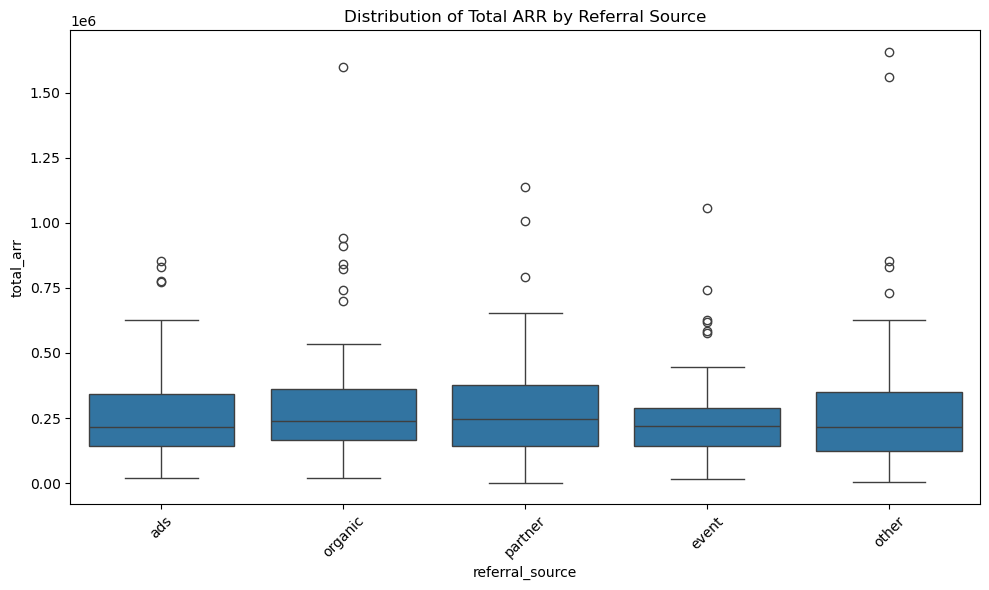

<Figure size 640x480 with 0 Axes>

In [93]:
# Boxplot to identify revenue/referral groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='referral_source', y='total_arr')
plt.xticks(rotation=45)
plt.title('Distribution of Total ARR by Referral Source')
plt.tight_layout()
plt.show()

plt.savefig('referral_arr_box.png', dpi=300, bbox_inches='tight')

In [94]:
# Obtain statistics to accompany above visual
referral_arr_stats = account_totals.groupby('referral_source')['total_arr'].describe()
print(referral_arr_stats)

                 count           mean            std      min       25%  \
referral_source                                                           
ads               98.0  262851.306122  178163.780668  21552.0  143385.0   
event             96.0  240181.250000  160964.819582  14136.0  144156.0   
organic          114.0  294600.736842  217959.191505  18720.0  164709.0   
other            103.0  277016.854369  257876.272696   5328.0  122928.0   
partner           89.0  282369.842697  202976.734063   2280.0  142824.0   

                      50%       75%        max  
referral_source                                 
ads              214524.0  341799.0   852240.0  
event            218634.0  289599.0  1055484.0  
organic          239268.0  363486.0  1599576.0  
other            214608.0  349416.0  1656720.0  
partner          245700.0  376992.0  1136520.0  


### Observations on potential clusters by referral source + arr

- Means and medians differ but distributions overlap heavily
- Continue search for cleaner k-means segmentation

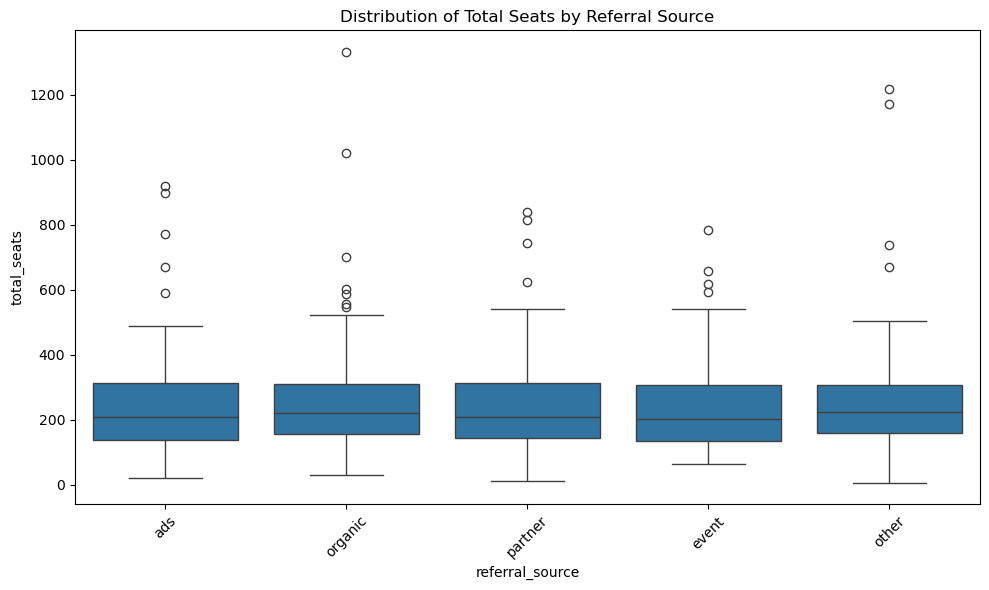

<Figure size 640x480 with 0 Axes>

In [95]:
# Boxplot to identify seats/referral groupings, if any
plt.figure(figsize=(10, 6))
sns.boxplot(data=account_totals, x='referral_source', y='total_seats')
plt.xticks(rotation=45)
plt.title('Distribution of Total Seats by Referral Source')
plt.tight_layout()
plt.show()

plt.savefig('referral_seats_box.png', dpi=300, bbox_inches='tight')

In [96]:
# Obtain statistics to accompany above visual
referral_seats_stats = account_totals.groupby('referral_source')['total_seats'].describe()
print(referral_seats_stats)

                 count        mean         std   min     25%    50%     75%  \
referral_source                                                               
ads               98.0  248.989796  167.371400  21.0  138.25  207.5  314.00   
event             96.0  235.104167  141.417000  62.0  134.75  203.0  305.00   
organic          114.0  260.903509  179.685318  29.0  155.00  219.0  308.25   
other            103.0  257.009709  183.800430   6.0  158.50  224.0  305.00   
partner           89.0  251.426966  162.537051  10.0  143.00  208.0  312.00   

                    max  
referral_source          
ads               920.0  
event             783.0  
organic          1332.0  
other            1218.0  
partner           840.0  


### Observations on potential clusters by referral source + seats

- Similar result to the previous ones, overlapping distributuons etc

- Next steps to review other data sources for candidates

### Exploration of alternative data sources for meaningful sgementation of customer accounts

- Shift focus to usage data as a behavioural metric

- Hypothesis: combining commercial (ARR) and behavioural (usage) data may reveal more distinct account segments than industry, country or referral source alone

In [97]:
# Create df to explore behavioural (usage) metrics with commercial features for potential segments
usage_subs = paid_customers.merge(fuse, on='subscription_id', how='left')

In [98]:
# Inspect results
usage_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21169 entries, 0 to 21168
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subscription_id      21169 non-null  object        
 1   account_id           21169 non-null  object        
 2   start_date           21169 non-null  datetime64[ns]
 3   end_date             1998 non-null   datetime64[ns]
 4   plan_tier            21169 non-null  object        
 5   seats                21169 non-null  int64         
 6   mrr_amount           21169 non-null  int64         
 7   arr_amount           21169 non-null  int64         
 8   is_trial             21169 non-null  bool          
 9   upgrade_flag         21169 non-null  bool          
 10  downgrade_flag       21169 non-null  bool          
 11  churn_flag           21169 non-null  bool          
 12  billing_frequency    21169 non-null  object        
 13  auto_renew_flag      21169 non-

In [99]:
# Aggegate usage metrics, grouping by account_id for account totals
usage_totals = usage_subs.groupby('account_id').agg(
    total_usage_count=('usage_count', 'sum'),
    total_usage_duration=('usage_duration_secs', 'sum')
).reset_index()

In [100]:
# Inspect results
usage_totals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   total_usage_count     500 non-null    float64
 2   total_usage_duration  500 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.8+ KB


In [101]:
# Merge 'usage_totals' with 'account_totals' from earlier exploration
size_usage = account_totals.merge(usage_totals, on='account_id', how='left')

In [102]:
# inspect results
size_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            500 non-null    object        
 1   total_arr             500 non-null    int64         
 2   total_seats           500 non-null    int64         
 3   account_name          500 non-null    object        
 4   industry              500 non-null    object        
 5   country               500 non-null    object        
 6   signup_date           500 non-null    datetime64[ns]
 7   referral_source       500 non-null    object        
 8   plan_tier             500 non-null    object        
 9   seats                 500 non-null    int64         
 10  is_trial              500 non-null    bool          
 11  churn_flag            500 non-null    bool          
 12  total_usage_count     500 non-null    float64       
 13  total_usage_duration

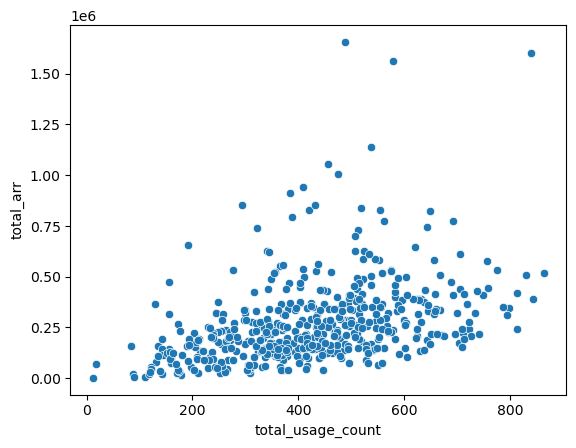

In [103]:
# Scatterplot total_arr and total_usage_count
scatter = sns.scatterplot(x='total_usage_count',
                          y='total_arr',
                          data=size_usage)
scatter.figure.savefig('scatterplot_arr_usage.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

 - 'total_arr' and 'total_usage' look more promising correlation

 - Run pairplots on remaining metrics to check for better combinations

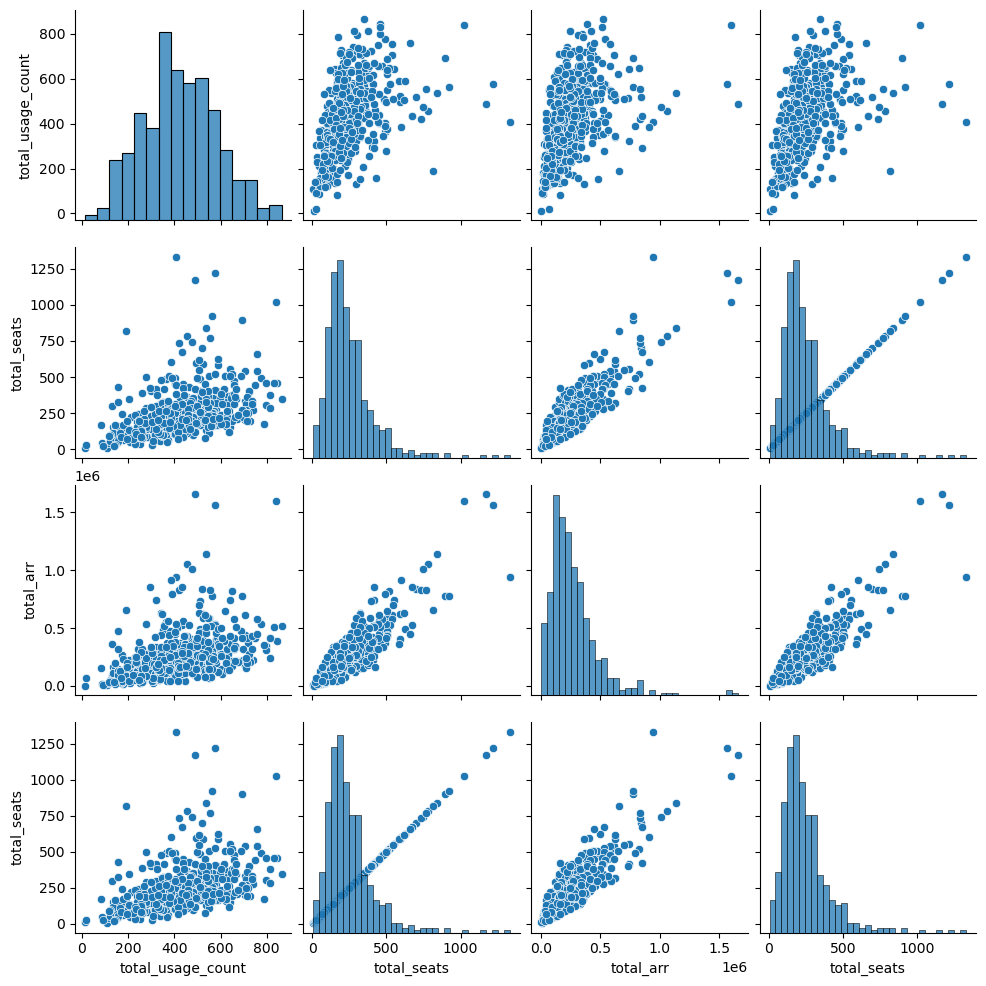

In [104]:
# Pairplot total_arr and total_usage_count
x = size_usage[['total_usage_count', 'total_seats', 'total_arr', 'total_seats']]
pairplot = sns.pairplot(size_usage,
                         vars=x)
pairplot.savefig('pairplot_usage_arr.png', dpi=300)

### Observation

 - Settled on 'total_arr' + 'total_usage'

 - Proceed to identify number of distinct groups

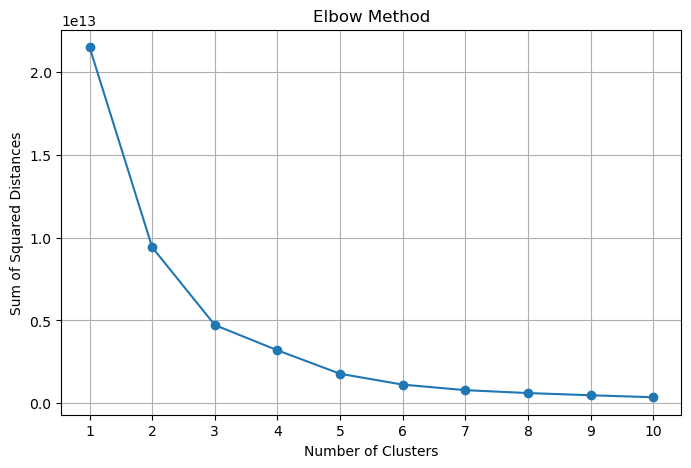

In [105]:
# Elbow method to identify separation
# Define x (total_arr and total_usage_count to combine commercial and behavioural factors to profile customers) 
x = size_usage[['total_arr', 'total_usage_count']]

# Elbow method code
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot it
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), ss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Sum of Squared Distances")
plt.grid(True)
plt.xticks(range(1, 11))
plt.savefig('elbow_1.png', dpi=300, bbox_inches='tight')
plt.show()

### Observation

From the Elbow visualisation, it appears that k=3. Generate silhoutte scores and compare k=2, k=3 and k=4 

In [106]:
# Fit k-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(size_usage[['total_arr', 'total_usage_count']])

# Add cluster labels to dataframe
size_usage['cluster'] = clusters

# Calculate silhouette score for k=3
score = silhouette_score(size_usage[['total_arr', 'total_usage_count']], clusters)
print(f"Silhouette score for k=3: {score:.3f}")

Silhouette score for k=3: 0.597


In [107]:
# Fit k-means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(size_usage[['total_arr', 'total_usage_count']])

# Calculate silhouette score for k=2
score = silhouette_score(size_usage[['total_arr', 'total_usage_count']], clusters)
print(f"Silhouette score for k=2: {score:.3f}")

Silhouette score for k=2: 0.654


In [108]:
# Fit k-means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(size_usage[['total_arr', 'total_usage_count']])

# Calculate silhouette score for k=4
score = silhouette_score(size_usage[['total_arr', 'total_usage_count']], clusters)
print(f"Silhouette score for k=4: {score:.3f}")

Silhouette score for k=4: 0.540


### Observations and next steps
Highest silhouette score for k=2. will label these as Core and Premier.
Next step, assign names to data.

In [109]:
# Fit k-means with 2 clusters (final model)
kmeans = KMeans(n_clusters=2, random_state=42)
size_usage['cluster'] = kmeans.fit_predict(size_usage[['total_arr', 'total_usage_count']])

# Check cluster centre statistics for naming ideas
print(kmeans.cluster_centers_)

[[6.33704615e+05 5.09974359e+02]
 [2.05298588e+05 4.08056872e+02]]


### Observations

 - Cluster 0 (first row): ARR approx 633,700 USD, usage approx 510

 - Cluster 1 (second row): ARR approx 205,300 USD, usage approx 408

Cluster 0 has significantly higher ARR and usage. 

- Name Cluster 0 'Premier'

- Cluster 1 will be 'Core'.

In [110]:
# Map cluster numbers to segment names
size_usage['segment'] = size_usage['cluster'].map({0: 'Premier', 1: 'Core'})

In [111]:
size_usage.head()

,account_id,total_arr,total_seats,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_usage_count,total_usage_duration,cluster,segment
0,A-00bed1,402072,314,Company_306,Cybersecurity,US,2023-11-14,ads,Basic,28,True,False,474.0,133851.0,1,Core
1,A-00cac8,169452,129,Company_26,HealthTech,AU,2023-09-15,organic,Enterprise,8,True,False,537.0,148616.0,1,Core
2,A-0158bb,48840,110,Company_461,FinTech,DE,2024-05-22,partner,Basic,5,False,False,260.0,89742.0,1,Core
3,A-016043,198192,154,Company_405,EdTech,CA,2024-07-31,organic,Basic,4,True,False,401.0,96687.0,1,Core
4,A-019782,100236,97,Company_142,DevTools,FR,2023-04-19,event,Enterprise,11,False,False,480.0,143122.0,1,Core


In [112]:
# Observe distritbution of segments
size_usage['segment'].value_counts()

segment
Core       422
Premier     78
Name: count, dtype: int64

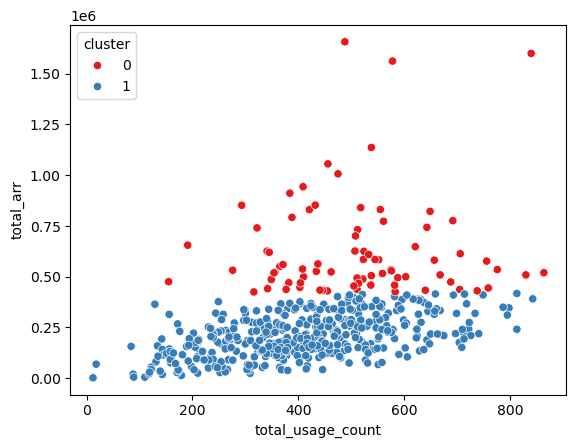

In [113]:
# Scatterplot with clusters coloured
scatter = sns.scatterplot(x='total_usage_count',
                          y='total_arr',
                          hue='cluster',
                          data=size_usage,
                          palette='Set1')
scatter.figure.savefig('scatterplot_arr_usage_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [114]:
size_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   account_id            500 non-null    object        
 1   total_arr             500 non-null    int64         
 2   total_seats           500 non-null    int64         
 3   account_name          500 non-null    object        
 4   industry              500 non-null    object        
 5   country               500 non-null    object        
 6   signup_date           500 non-null    datetime64[ns]
 7   referral_source       500 non-null    object        
 8   plan_tier             500 non-null    object        
 9   seats                 500 non-null    int64         
 10  is_trial              500 non-null    bool          
 11  churn_flag            500 non-null    bool          
 12  total_usage_count     500 non-null    float64       
 13  total_usage_duration

In [115]:
# Merge segment labels into new master accounts and segments df
raccs_segment = raccs.merge(size_usage[['account_id', 'segment']], on='account_id', how='left')

In [116]:
raccs_segment.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,segment
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,Core
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,Core
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,Core
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,Core
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,Premier


### Segmentation conclusion: Total arr + total usage
 
 -  To my eye, thought there appeared to be three, possibly four groups
 -  Elbow chart appeared to indicate three
 -  Silhoutte score concluded there were only two segments
 -  The final scatter plot shows that usage varies across the full range in both groups
 -  There are no "high usage/high arr" and "low usage/low arr" groupings as hoped
 -  As a temporary measure, explore revenue and seat count to group along purely commerical lines and revisit later to identify behavoural features  

In [117]:
account_totals.head()

,account_id,total_arr,total_seats,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-00bed1,402072,314,Company_306,Cybersecurity,US,2023-11-14,ads,Basic,28,True,False
1,A-00cac8,169452,129,Company_26,HealthTech,AU,2023-09-15,organic,Enterprise,8,True,False
2,A-0158bb,48840,110,Company_461,FinTech,DE,2024-05-22,partner,Basic,5,False,False
3,A-016043,198192,154,Company_405,EdTech,CA,2024-07-31,organic,Basic,4,True,False
4,A-019782,100236,97,Company_142,DevTools,FR,2023-04-19,event,Enterprise,11,False,False


In [118]:
# Create a fresh dataframe for ARR + seats segmentation
cluster_final = account_totals[['account_id', 'total_arr', 'total_seats']].copy()

In [119]:
cluster_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   account_id   500 non-null    object
 1   total_arr    500 non-null    int64 
 2   total_seats  500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


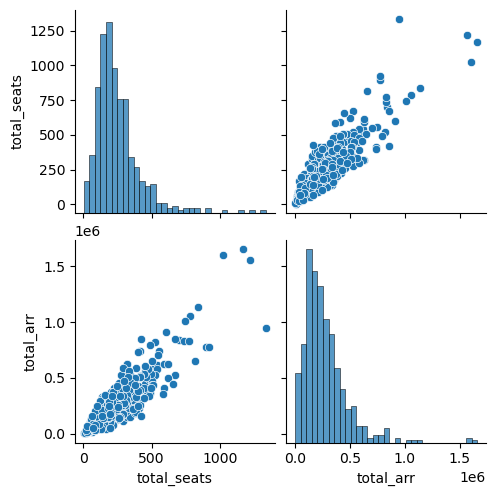

In [120]:
# Create a pairplot with Seaborn and export as png
x = cluster_final[['total_seats', 'total_arr']]
pairplot = sns.pairplot(cluster_final, vars=x)
pairplot.savefig('pairplot_final.png', dpi=300)

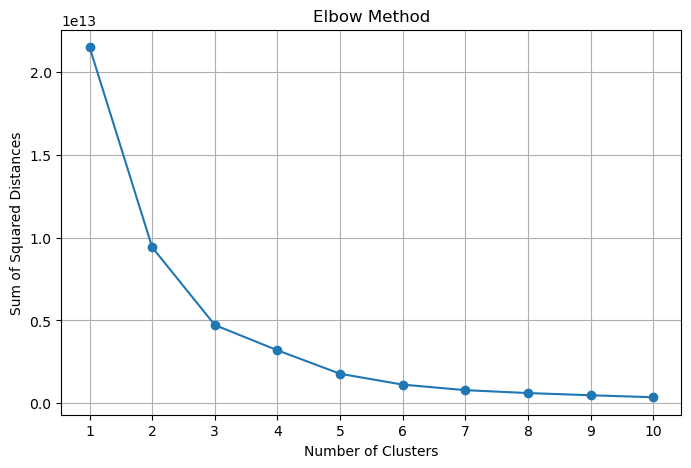

In [121]:
# Elbow method to identify separation
# Define x (only total_arr and total seats in df) 
x = cluster_final[['total_arr', 'total_seats']]

# Elbow method code
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot it
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), ss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Sum of Squared Distances")
plt.grid(True)
plt.xticks(range(1, 11))
plt.savefig('elbow_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [122]:
# Generate silhouette scores to resolve whether bend there are 2 or 3 clusters
x = cluster_final[['total_arr', 'total_seats']]

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.654
k=3, silhouette score=0.597
k=4, silhouette score=0.540
k=5, silhouette score=0.541


### Observation

- Elbow appears to indicate k=3

- Silhoute indicates k=2

- Proceed with two segments (higher value and lower value customers)

In [123]:
# Fit k-means with 2 clusters (final model)
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_final['cluster'] = kmeans.fit_predict(size_usage[['total_arr', 'total_usage_count']])

# Check cluster centre statistics
print(kmeans.cluster_centers_)

[[6.33704615e+05 5.09974359e+02]
 [2.05298588e+05 4.08056872e+02]]


 - Cluster 0 has higher ARR (approx 633k) and seats ( approx 510): retain label 'Premier'

 - Cluster 1 has lower ARR (approx 205k) and seats ( approx 408): : retain label 'Core'

In [124]:
# Map cluster numbers to segment names
cluster_final['segment'] = cluster_final['cluster'].map({0: 'Premier', 1: 'Core'})

In [125]:
cluster_final.head()

,account_id,total_arr,total_seats,cluster,segment
0,A-00bed1,402072,314,1,Core
1,A-00cac8,169452,129,1,Core
2,A-0158bb,48840,110,1,Core
3,A-016043,198192,154,1,Core
4,A-019782,100236,97,1,Core


In [126]:
# Observe distritbution of segments
cluster_final['segment'].value_counts()

segment
Core       422
Premier     78
Name: count, dtype: int64

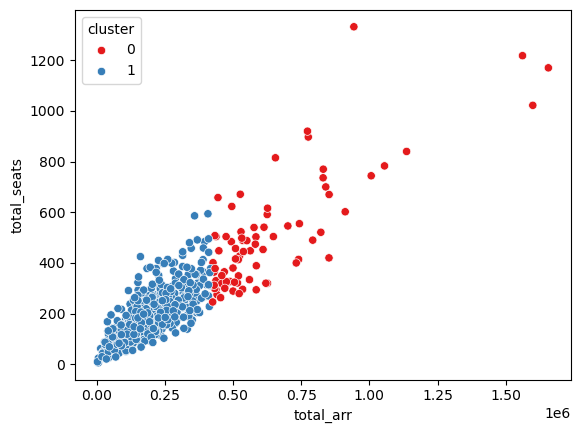

In [127]:
# Scatterplot with clusters coloured
scatter = sns.scatterplot(x='total_arr',
                          y='total_seats',
                          hue='cluster',
                          data=cluster_final,
                          palette='Set1')
scatter.figure.savefig('scatterplot_arr_seats_final.png', dpi=300, bbox_inches='tight')
plt.show()

### Clustering observations/conclusions/next steps here

## Health scoring

We are using data from Feature Usage and Support Tickets for this framework. Support Tickets does not include subsciption_ids, for some reason, it is only recorded at account level, which is a flaw and a limitation. For that reason, will need to wrangle feature usage data to aggregate to account level before merging with support ticket data.

In [128]:
# Group usage data by subscription_id to create one row per subscription
usage_account = usage_subs.groupby('account_id').agg(
    avg_usage_count=('usage_count', 'mean'),
    distinct_features=('feature_name', 'nunique')
    ).reset_index()

In [129]:
usage_account.head()

,account_id,avg_usage_count,distinct_features
0,A-00bed1,10.304348,29
1,A-00cac8,10.529412,30
2,A-0158bb,10.000000,15
3,A-016043,10.282051,24
4,A-019782,10.434783,25


In [130]:
# Support ticket data has nulls where there was no response to satisfaction survey
# First create a copy df to use for imputation
stix_clean = stix.copy()

In [131]:
# Calculate customer mean satisfaction, ignoring nulls
customer_sat_mean = stix_clean.groupby('account_id')['satisfaction_score'].transform('mean')

In [132]:
# Calculate the global satisfaction mean to obtain a value for customers with no score recorded
global_sat_mean = stix_clean['satisfaction_score'].mean()

In [133]:
# Create a new column "sat_score" which will contain either the account mean or the global mean if no score available
stix_clean['sat_score'] = stix_clean['satisfaction_score'].fillna(customer_sat_mean).fillna(global_sat_mean)

In [134]:
stix_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ticket_id                    2000 non-null   object        
 1   account_id                   2000 non-null   object        
 2   submitted_at                 2000 non-null   datetime64[ns]
 3   closed_at                    2000 non-null   datetime64[ns]
 4   resolution_time_hours        2000 non-null   float64       
 5   priority                     2000 non-null   object        
 6   first_response_time_minutes  2000 non-null   int64         
 7   satisfaction_score           1175 non-null   float64       
 8   escalation_flag              2000 non-null   bool          
 9   sat_score                    2000 non-null   float64       
dtypes: bool(1), datetime64[ns](2), float64(3), int64(1), object(3)
memory usage: 142.7+ KB


In [135]:
# Aggregate support metrics to account level (one row per account)
support_agg = stix_clean.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_resolution_hours=('resolution_time_hours', 'mean'),
    avg_sat_score=('sat_score', 'mean')
).reset_index()

In [136]:
support_agg.head()

,account_id,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,4,31.750000,4.000000
1,A-00cac8,2,33.000000,3.981277
2,A-0158bb,1,32.000000,3.000000
3,A-016043,3,30.333333,4.000000
4,A-019782,2,10.000000,3.000000


In [137]:
# Merge usage totals with ticket totals
health_data = usage_account.merge(support_agg, on='account_id', how='left')

In [138]:
health_data.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,10.304348,29,4.0,31.750000,4.000000
1,A-00cac8,10.529412,30,2.0,33.000000,3.981277
2,A-0158bb,10.000000,15,1.0,32.000000,3.000000
3,A-016043,10.282051,24,3.0,30.333333,4.000000
4,A-019782,10.434783,25,2.0,10.000000,3.000000


In [139]:
# Check for any remaining nulls
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    int64  
 3   total_tickets         492 non-null    float64
 4   avg_resolution_hours  492 non-null    float64
 5   avg_sat_score         492 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


In [140]:
# Fill support data nulls with 0 (no tickets raised = zero support activity)
health_data['total_tickets'] = health_data['total_tickets'].fillna(0)
health_data['avg_resolution_hours'] = health_data['avg_resolution_hours'].fillna(0)
health_data['avg_sat_score'] = health_data['avg_sat_score'].fillna(0)

In [141]:
# Inspect results
health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    int64  
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


In [142]:
# Create a copy form normalisation
health_data_scaled = health_data.copy()

In [143]:
# Select columns to normalise
norm_cols = [
    'avg_usage_count', 'distinct_features', 'total_tickets', 'avg_resolution_hours', 'avg_sat_score'
]

In [144]:
# Apply MinMaxScaler
scaler = MinMaxScaler()
health_data_scaled[norm_cols] = scaler.fit_transform(health_data[norm_cols])

In [145]:
# Inspect results
health_data_scaled.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score
0,A-00bed1,0.771299,0.729730,0.363636,0.440972,0.800000
1,A-00cac8,0.811629,0.756757,0.181818,0.458333,0.796255
2,A-0158bb,0.716763,0.351351,0.090909,0.444444,0.600000
3,A-016043,0.767304,0.594595,0.272727,0.421296,0.800000
4,A-019782,0.794672,0.621622,0.181818,0.138889,0.600000


In [146]:
# Check dtypes and for any remaining nulls
health_data_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   avg_usage_count       500 non-null    float64
 2   distinct_features     500 non-null    float64
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
dtypes: float64(5), object(1)
memory usage: 23.6+ KB


### Health Score Weighting Summary

Geoffrey Weiss's white paper provides this example that weighting a health scoring framework might include

 - Product usage (depth and breadth): 30%
 - Executive engagement frequency: 25%
 - Support ticket volume and sentiment: 15%
 - Contract renewal timeline: 10%
 - User growth/adoption rates: 10%
 - Invoice payment history: 10%

The data does not provide;

 - Executive engagement. The only survey appears to be on closure of support ticket.  User level satisfaction is the only level of customer engagement captured.
 - Billing metrics (Contract renewal timeline & Invoice payment history). No data provided.

For V1, health scoring will be weighted as follows, based on the available data:

Usage (50%)
 - distinct_features (Usage depth): 25%
 - avg_usage_count (Usage breadth): 25%

Support (50%)
 - avg_sat_score: 30%
 - total_tickets: 10%
 - avg_resolution_hours: 10%

50/50 split Usage and Support. Rationale without the aforementioned measures, we can only gather usage breadth and depth and use support activity as a proxy for all customer engagement. 

In [147]:
# Calculate health score using documented weighting
health_data_scaled['health_score'] = (
    # Product usage (50%)
    (health_data_scaled['distinct_features'] * 0.25) +
    (health_data_scaled['avg_usage_count'] * 0.25) +
    # Support (50%)
    (health_data_scaled['avg_sat_score'] * 0.30) +
    (health_data_scaled['total_tickets'] * 0.10) +
    (health_data_scaled['avg_resolution_hours'] * 0.10)
)

# Scale to 0-100
health_data_scaled['health_score'] = health_data_scaled['health_score'] * 100

In [148]:
health_data_scaled['health_score'].describe()

count    500.000000
mean      65.682510
std        7.743390
min       21.243375
25%       62.269857
50%       66.813991
75%       70.403928
max       80.463568
Name: health_score, dtype: float64

In [149]:
# Bring in segment column
health_scoring = health_data_scaled.merge(cluster_final, on='account_id', how='left')

In [150]:
# Check df
health_scoring.head()

,account_id,avg_usage_count,distinct_features,total_tickets,avg_resolution_hours,avg_sat_score,health_score,total_arr,total_seats,cluster,segment
0,A-00bed1,0.771299,0.729730,0.363636,0.440972,0.800000,69.571812,402072,314,1,Core
1,A-00cac8,0.811629,0.756757,0.181818,0.458333,0.796255,69.498811,169452,129,1,Core
2,A-0158bb,0.716763,0.351351,0.090909,0.444444,0.600000,50.056394,48840,110,1,Core
3,A-016043,0.767304,0.594595,0.272727,0.421296,0.800000,64.987700,198192,154,1,Core
4,A-019782,0.794672,0.621622,0.181818,0.138889,0.600000,56.614412,100236,97,1,Core


In [151]:
# Retain key metrics only for this dataframe
health_scoring.drop(['avg_usage_count', 'distinct_features', 'total_tickets', 'avg_resolution_hours', 'cluster'], axis=1, inplace=True)

In [152]:
# Check finalised dataframe
health_scoring.head()

,account_id,avg_sat_score,health_score,total_arr,total_seats,segment
0,A-00bed1,0.800000,69.571812,402072,314,Core
1,A-00cac8,0.796255,69.498811,169452,129,Core
2,A-0158bb,0.600000,50.056394,48840,110,Core
3,A-016043,0.800000,64.987700,198192,154,Core
4,A-019782,0.600000,56.614412,100236,97,Core


In [153]:
# Obtain statistics for segments
health_scoring.groupby('segment')['health_score'].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
Core,422.0,65.289811,7.911976,21.243375,61.742435,66.427635,70.209152,80.463568
Premier,78.0,67.807113,6.394586,39.836319,65.248640,68.695746,71.244205,80.086893


### Health scoring conclusion
Health scores ranged from 21 to 80, with a mean of 66 and standard deviation 7.7. The tight distribution reflects the synthetic nature of the data; in a real-world dataset, we would expect wider variation and clearer differentiation between healthy and at-risk accounts.

Across segments, Premier has higher mean health (67.8 vs 65.3) and slightly lower variance (std 6.4 vs 7.9). That is consistent with what you would expect: higher-value accounts are healthier on average. However the differences are less pronounced than we may expect and likely another signal about the synthetic nature of this data.

## Churn prediction
Churn is recorded at subscription level ('churn_flag'). Feature usage is also recorded at subscription level.
Despite all churn event reason codes being fairly equally distributed, 'features' was the #1 reson code (19%).

Merge subscriptions and feature usage to see if we get sufficiently strong enough signals for churn prediction.

In [154]:
# Select the needed columns from subscriptions
base_data = subs[['subscription_id', 'account_id', 'plan_tier', 'seats', 'arr_amount', 'upgrade_flag', 'downgrade_flag', 'auto_renew_flag', 'churn_flag']]

In [155]:
base_data.head()

,subscription_id,account_id,plan_tier,seats,arr_amount,upgrade_flag,downgrade_flag,auto_renew_flag,churn_flag
0,S-8cec59,A-3c1a3f,Enterprise,14,33432,False,False,True,True
1,S-0f6f44,A-9b9fe9,Pro,17,9996,False,False,True,False
2,S-51c0d1,A-659280,Enterprise,62,0,True,False,False,False
3,S-f81687,A-e7a1e2,Enterprise,5,11940,False,False,True,True
4,S-cff5a2,A-ba6516,Enterprise,27,64476,False,False,True,False


In [156]:
# Apply one-hot encodng on 'plan_tier' column
base_data = pd.get_dummies(base_data, columns=['plan_tier'], drop_first=False, dtype=int)

In [157]:
base_data.head()

,subscription_id,account_id,seats,arr_amount,upgrade_flag,downgrade_flag,auto_renew_flag,churn_flag,plan_tier_Basic,plan_tier_Enterprise,plan_tier_Pro
0,S-8cec59,A-3c1a3f,14,33432,False,False,True,True,0,1,0
1,S-0f6f44,A-9b9fe9,17,9996,False,False,True,False,0,0,1
2,S-51c0d1,A-659280,62,0,True,False,False,False,0,1,0
3,S-f81687,A-e7a1e2,5,11940,False,False,True,True,0,1,0
4,S-cff5a2,A-ba6516,27,64476,False,False,True,False,0,1,0


In [158]:
# Create a new dataframe from feature usage with one-hot encoded values from the 'feature_usage' column
fuse_churn = pd.get_dummies(fuse, columns=['feature_name'], drop_first=True, dtype=int)

In [159]:
fuse_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   usage_id                 25000 non-null  int64         
 1   subscription_id          25000 non-null  object        
 2   usage_date               25000 non-null  datetime64[ns]
 3   usage_count              25000 non-null  int64         
 4   usage_duration_secs      25000 non-null  int64         
 5   error_count              25000 non-null  int64         
 6   is_beta_feature          25000 non-null  bool          
 7   feature_name_feature_10  25000 non-null  int32         
 8   feature_name_feature_11  25000 non-null  int32         
 9   feature_name_feature_12  25000 non-null  int32         
 10  feature_name_feature_13  25000 non-null  int32         
 11  feature_name_feature_14  25000 non-null  int32         
 12  feature_name_feature_15  25000 n

In [160]:
# Drop is_beta_feature, not using in model
fuse_churn = fuse_churn.drop('is_beta_feature', axis=1)

In [161]:
# Group by subscription_id and aggregate
fuse_churn_agg = fuse_churn.groupby('subscription_id').agg({
    # Sum numeric usage metrics
    'usage_count': 'sum',
    'usage_duration_secs': 'sum',
    'error_count': 'sum',
    
    # For one-hot encoded features use max, ie 1 if ever used
    'feature_name_feature_10': 'max',
    'feature_name_feature_11': 'max',
    'feature_name_feature_12': 'max',
    'feature_name_feature_13': 'max',
    'feature_name_feature_14': 'max',
    'feature_name_feature_15': 'max',
    'feature_name_feature_16': 'max',
    'feature_name_feature_17': 'max',
    'feature_name_feature_18': 'max',
    'feature_name_feature_19': 'max',
    'feature_name_feature_2': 'max',
    'feature_name_feature_20': 'max',
    'feature_name_feature_21': 'max',
    'feature_name_feature_22': 'max',
    'feature_name_feature_23': 'max',
    'feature_name_feature_24': 'max',
    'feature_name_feature_25': 'max',
    'feature_name_feature_26': 'max',
    'feature_name_feature_27': 'max',
    'feature_name_feature_28': 'max',
    'feature_name_feature_29': 'max',
    'feature_name_feature_3': 'max',
    'feature_name_feature_30': 'max',
    'feature_name_feature_31': 'max',
    'feature_name_feature_32': 'max',
    'feature_name_feature_33': 'max',
    'feature_name_feature_34': 'max',
    'feature_name_feature_35': 'max',
    'feature_name_feature_36': 'max',
    'feature_name_feature_37': 'max',
    'feature_name_feature_38': 'max',
    'feature_name_feature_39': 'max',
    'feature_name_feature_4': 'max',
    'feature_name_feature_40': 'max',
    'feature_name_feature_5': 'max',
    'feature_name_feature_6': 'max',
    'feature_name_feature_7': 'max',
    'feature_name_feature_8': 'max',
    'feature_name_feature_9': 'max'
})

In [162]:
fuse_churn_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4967 entries, S-001561 to S-fffeb8
Data columns (total 42 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   usage_count              4967 non-null   int64
 1   usage_duration_secs      4967 non-null   int64
 2   error_count              4967 non-null   int64
 3   feature_name_feature_10  4967 non-null   int32
 4   feature_name_feature_11  4967 non-null   int32
 5   feature_name_feature_12  4967 non-null   int32
 6   feature_name_feature_13  4967 non-null   int32
 7   feature_name_feature_14  4967 non-null   int32
 8   feature_name_feature_15  4967 non-null   int32
 9   feature_name_feature_16  4967 non-null   int32
 10  feature_name_feature_17  4967 non-null   int32
 11  feature_name_feature_18  4967 non-null   int32
 12  feature_name_feature_19  4967 non-null   int32
 13  feature_name_feature_2   4967 non-null   int32
 14  feature_name_feature_20  4967 non-null   int32
 15

In [163]:
# Merge usage data with the subscription data in base_data
base_data = base_data.merge(fuse_churn_agg, on='subscription_id', how='left')

In [164]:
base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subscription_id          5000 non-null   object 
 1   account_id               5000 non-null   object 
 2   seats                    5000 non-null   int64  
 3   arr_amount               5000 non-null   int64  
 4   upgrade_flag             5000 non-null   bool   
 5   downgrade_flag           5000 non-null   bool   
 6   auto_renew_flag          5000 non-null   bool   
 7   churn_flag               5000 non-null   bool   
 8   plan_tier_Basic          5000 non-null   int32  
 9   plan_tier_Enterprise     5000 non-null   int32  
 10  plan_tier_Pro            5000 non-null   int32  
 11  usage_count              4967 non-null   float64
 12  usage_duration_secs      4967 non-null   float64
 13  error_count              4967 non-null   float64
 14  feature_name_feature_10 

In [165]:
# Fill nulls in usage columns to indicate no usage
base_data = base_data.fillna(0)

In [166]:
# Inspect results before moving on to create the data frame to be used by the decision tree classifier
base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subscription_id          5000 non-null   object 
 1   account_id               5000 non-null   object 
 2   seats                    5000 non-null   int64  
 3   arr_amount               5000 non-null   int64  
 4   upgrade_flag             5000 non-null   bool   
 5   downgrade_flag           5000 non-null   bool   
 6   auto_renew_flag          5000 non-null   bool   
 7   churn_flag               5000 non-null   bool   
 8   plan_tier_Basic          5000 non-null   int32  
 9   plan_tier_Enterprise     5000 non-null   int32  
 10  plan_tier_Pro            5000 non-null   int32  
 11  usage_count              5000 non-null   float64
 12  usage_duration_secs      5000 non-null   float64
 13  error_count              5000 non-null   float64
 14  feature_name_feature_10 

In [167]:
# Create copy for use in decision tree classifier
predict_1 = base_data.copy()

In [168]:
# Define X (features) and y (target)
X = predict_1.drop(['subscription_id', 'account_id', 'churn_flag'], axis=1)
y = predict_1['churn_flag']

In [169]:
# Create a new DataFrame and apply SMOTE as the target variable is not balanced.
os = SMOTE(random_state=0)  

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=0)

# Specify column values.
columns = X_train.columns  
# Specify the new data sets.
os_data_X,os_data_y=os.fit_resample(X_train, y_train)  

# Create two DataFrames for X and one for y.
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['churn_flag'])

# Print/check the DataFrame.
print("Length of oversampled data is ",len(os_data_X))
os_data_y

Length of oversampled data is  6288


,churn_flag
0,False
1,False
2,False
3,False
4,False
...,...
6283,True
6284,True
6285,True
6286,True


In [170]:
# Determine if values in a column are balanced after running SMOTE
os_data_y['churn_flag'].value_counts()

churn_flag
False    3144
True     3144
Name: count, dtype: int64

In [171]:
# Create a classification decision tree classifier object as dtc. 
dtc = DecisionTreeClassifier(criterion='gini',
                             max_depth=4,
                             random_state=1)

# Train the decision tree classifier.
dtc = dtc.fit(os_data_X, os_data_y) 

# Predict the response for the test data set.
y_pred = dtc.predict(X_test)

In [172]:
# Use the print() function to display the confusion matrix results.
print(confusion_matrix(y_test, y_pred))

# Metrics for accuracy: (TP + TN)/(TP + FP + TN + FN).
print("Accuracy:",metrics.accuracy_score(y_test, y_pred)) 

# Metrics for precision: TP/(TP + FP).
print("Precision:",metrics.precision_score(y_test, y_pred)) 

# Metrics for recall: TP/(FN + TP).
print("Recall:",metrics.recall_score(y_test, y_pred))

[[662 708]
 [ 58  72]]
Accuracy: 0.48933333333333334
Precision: 0.09230769230769231
Recall: 0.5538461538461539


### Confusion matrix observations
Recall is 0.55. Precision is 0.09. The model catches just over half of churners but flags many false positives.

Features are weak. The model cannot distinguish churners well.

In [173]:
#  Look at feature importance to see which features the model is using
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dtc.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

                    feature  importance
43   feature_name_feature_4    0.550836
18  feature_name_feature_17    0.290183
7             plan_tier_Pro    0.103837
39  feature_name_feature_36    0.044941
31  feature_name_feature_29    0.004488
33  feature_name_feature_30    0.003549
1                arr_amount    0.001719
8               usage_count    0.000446
37  feature_name_feature_34    0.000000
29  feature_name_feature_27    0.000000


### Subscription/Feature Usage model conclusion
'feature_4' accounts for 55% of importance, the model depends almost entirely on a single feature.
More evidence of the artificial nature of this data set. I cannot predict churn at anything like the reliability required at subscription level.

Support ticket data includes "satisfaction score". Support ticket data is at account level, which includes a 'churn_flag' for cumulative churn across all subscriptions under the parent account_id. Attempt to model at account level using revenue data and support ticket data.

In [174]:
# Create a copy of merged accounts/subscriptions df that has trial customers removed from it
# Obtain only required fields for identification and aggregation
ch_subs = paid_customers[['account_id', 'subscription_id', 'seats', 'arr_amount']].copy()

In [175]:
ch_subs_agg = ch_subs.groupby('account_id').agg({
    'seats': 'sum',
    'arr_amount': 'sum'
}).reset_index()

In [176]:
ch_subs_agg.head()

,account_id,seats,arr_amount
0,A-00bed1,314,402072
1,A-00cac8,129,169452
2,A-0158bb,110,48840
3,A-016043,154,198192
4,A-019782,97,100236


In [177]:
ch_subs_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   account_id  500 non-null    object
 1   seats       500 non-null    int64 
 2   arr_amount  500 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 11.8+ KB


In [178]:
# Reuse 'support_agg' df for aggregated support ticket data from health scoring
support_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            492 non-null    object 
 1   total_tickets         492 non-null    int64  
 2   avg_resolution_hours  492 non-null    float64
 3   avg_sat_score         492 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 15.5+ KB


In [179]:
# Merge aggregated support metrics with aggregated subscription totals 
ch_subs_tix = ch_subs_agg.merge(support_agg, on='account_id', how='left')

In [180]:
ch_subs_tix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   seats                 500 non-null    int64  
 2   arr_amount            500 non-null    int64  
 3   total_tickets         492 non-null    float64
 4   avg_resolution_hours  492 non-null    float64
 5   avg_sat_score         492 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 23.6+ KB


In [181]:
# Address nulls where no activity recorded, replace with 0 where 0 tickets logged
# Use middle of scale for sat score nulls (3 in 1-5 scale)
ch_subs_tix['total_tickets'] = ch_subs_tix['total_tickets'].fillna(0)
ch_subs_tix['avg_resolution_hours'] = ch_subs_tix['avg_resolution_hours'].fillna(0)
ch_subs_tix['avg_sat_score'] = ch_subs_tix['avg_sat_score'].fillna(3.0)

In [182]:
# Final check for nulls
ch_subs_tix.isnull().sum()

account_id              0
seats                   0
arr_amount              0
total_tickets           0
avg_resolution_hours    0
avg_sat_score           0
dtype: int64

In [183]:
# Merge with accounts dataframe to get 'churn'flag' column
ch_subs_tix = ch_subs_tix.merge(raccs[['account_id', 'churn_flag']], on='account_id', how='left')

In [184]:
# Final check of features for 'account level with support ticket data' churn prediction model
ch_subs_tix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   seats                 500 non-null    int64  
 2   arr_amount            500 non-null    int64  
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
 6   churn_flag            500 non-null    bool   
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 24.1+ KB


In [185]:
# Create copy for use in decision tree classifier
predict_2 = ch_subs_tix.copy()

In [186]:
# Define X (features) and y (target)
X = predict_2.drop(['churn_flag', 'account_id'], axis=1)
y = predict_2['churn_flag']

In [187]:
# Create a new DataFrame and apply SMOTE as the target variable is not balanced.
os = SMOTE(random_state=0)  

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=0)

# Specify column values.
columns = X_train.columns  
# Specify the new data sets.
os_data_X,os_data_y=os.fit_resample(X_train, y_train)  

# Create two DataFrames for X and one for y.
os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['churn_flag'])

# Print/check the DataFrame.
print("Length of oversampled data is ",len(os_data_X))
os_data_y

Length of oversampled data is  550


,churn_flag
0,True
1,False
2,False
3,False
4,False
...,...
545,True
546,True
547,True
548,True


In [188]:
# Determine if values in a column are balanced
os_data_y['churn_flag'].value_counts()

churn_flag
True     275
False    275
Name: count, dtype: int64

In [189]:
# Create a classification decision tree classifier object as dtc. 
dtc = DecisionTreeClassifier(criterion='gini',
                             max_depth=3,
                             random_state=1)

# Train the decision tree classifier.
dtc = dtc.fit(os_data_X, os_data_y) 

# Predict the response for the test data set.
y_pred = dtc.predict(X_test)

In [190]:
# Use the print() function to display the confusion matrix results.
print(confusion_matrix(y_test, y_pred))

# Metrics for accuracy: (TP + TN)/(TP + FP + TN + FN).
print("Accuracy:",metrics.accuracy_score(y_test, y_pred)) 

# Metrics for precision: TP/(TP + FP).
print("Precision:",metrics.precision_score(y_test, y_pred)) 

# Metrics for recall: TP/(FN + TP).
print("Recall:",metrics.recall_score(y_test, y_pred))

[[52 63]
 [19 16]]
Accuracy: 0.4533333333333333
Precision: 0.20253164556962025
Recall: 0.45714285714285713


In [191]:
#  Look at feature importance to see which features the model is using
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dtc.feature_importances_
}).sort_values('importance', ascending=False)
print(importance.head(10))

                feature  importance
4         avg_sat_score    0.931835
3  avg_resolution_hours    0.054602
0                 seats    0.013563
1            arr_amount    0.000000
2         total_tickets    0.000000


### Conclusions
Satisfaction score is the dominant predictor. This is a reasonable proxy for churn risk (unhappy customers leave), but the model lacks balance.

Precision is only 20%, which means five customers are highlighted as flight risk when only one of them is genuine. That said, the cost of churn is far higher than the cost of a plan to contact all five customers as part of an intervention plan.

Make recommendations for data to be captured by RavenStack for more reliable modelling going forwards.

In [192]:
# Merge churn prediction df with health/segment data
csm_dash = predict_2.merge(health_scoring[['account_id', 'health_score', 'total_arr','total_seats',  'segment']], on='account_id', how='left')

In [194]:
# Predict churn probability using model (column index 1 = score probability of churn on scale between 0, less likely & 1, more likely)
csm_dash['churn_prob'] = dtc.predict_proba(csm_dash[['seats', 'arr_amount', 'total_tickets', 'avg_resolution_hours', 'avg_sat_score']])[:, 1]

In [195]:
# This dataframe now contains key metrics resulting from this workflow (segmentation, health score and churn prediction)
# Includes other leading indicators for comprehensive snapshot of the customer for use in dashboards
csm_dash.head()

,account_id,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,churn_flag,health_score,total_arr,total_seats,segment,churn_prob
0,A-00bed1,314,402072,4.0,31.750000,4.000000,False,69.571812,402072,314,Core,0.303704
1,A-00cac8,129,169452,2.0,33.000000,3.981277,False,69.498811,169452,129,Core,0.303704
2,A-0158bb,110,48840,1.0,32.000000,3.000000,False,50.056394,48840,110,Core,0.045455
3,A-016043,154,198192,3.0,30.333333,4.000000,False,64.987700,198192,154,Core,0.303704
4,A-019782,97,100236,2.0,10.000000,3.000000,False,56.614412,100236,97,Core,0.307692


In [197]:
# Create Premier segment dashboard
csm_dash_prem = csm_dash[csm_dash['segment'] == 'Premier'].copy().reset_index(drop=True)

In [199]:
# Create Core segment dashboard
csm_dash_core = csm_dash[csm_dash['segment'] == 'Core'].copy().reset_index(drop=True)

In [202]:
# Statistics from all dashboards, all customers
csm_dash.describe()

,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000
mean,251.126000,2.721299e+05,4.000000,35.658699,3.949626,65.682510,2.721299e+05,251.126000,0.432275
std,167.952237,2.075382e+05,1.892925,12.580350,0.563840,7.743390,2.075382e+05,167.952237,0.177345
min,6.000000,2.280000e+03,0.000000,0.000000,3.000000,21.243375,2.280000e+03,6.000000,0.000000
25%,148.000000,1.426110e+05,3.000000,28.666667,3.500000,62.269857,1.426110e+05,148.000000,0.303704
50%,211.000000,2.260020e+05,4.000000,35.633333,4.000000,66.813991,2.260020e+05,211.000000,0.526316
75%,312.250000,3.464970e+05,5.000000,43.000000,4.333333,70.403928,3.464970e+05,312.250000,0.590476
max,1332.000000,1.656720e+06,11.000000,72.000000,5.000000,80.463568,1.656720e+06,1332.000000,1.000000


In [203]:
# Statistics from all dashboards, Premier customers
csm_dash_prem.describe()

,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,78.000000,7.800000e+01,78.000000,78.000000,78.000000,78.000000,7.800000e+01,78.000000,78.000000
mean,506.025641,6.337046e+05,3.910256,38.471281,3.914023,67.807113,6.337046e+05,506.025641,0.456781
std,226.923294,2.547954e+05,1.824693,12.294732,0.577404,6.394586,2.547954e+05,226.923294,0.171669
min,246.000000,4.250880e+05,0.000000,0.000000,3.000000,39.836319,4.250880e+05,246.000000,0.000000
25%,327.750000,4.744860e+05,3.000000,31.083333,3.500000,65.248640,4.744860e+05,327.750000,0.303704
50%,450.500000,5.349900e+05,4.000000,38.116667,4.000000,68.695746,5.349900e+05,450.500000,0.526316
75%,582.000000,7.239420e+05,5.000000,45.800000,4.312500,71.244205,7.239420e+05,582.000000,0.590476
max,1332.000000,1.656720e+06,9.000000,70.500000,5.000000,80.086893,1.656720e+06,1332.000000,1.000000


In [204]:
# Statistics from all dashboards, Core customers
csm_dash_core.describe()

,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,health_score,total_arr,total_seats,churn_prob
count,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000
mean,204.011848,205298.587678,4.016588,35.138838,3.956207,65.289811,205298.587678,204.011848,0.427745
std,98.757446,102368.988813,1.906909,12.577919,0.561749,7.911976,102368.988813,98.757446,0.178204
min,6.000000,2280.000000,0.000000,0.000000,3.000000,21.243375,2280.000000,6.000000,0.000000
25%,135.250000,129063.000000,3.000000,28.458333,3.600000,61.742435,129063.000000,135.250000,0.303704
50%,190.500000,198216.000000,4.000000,34.733333,4.000000,66.427635,198216.000000,190.500000,0.526316
75%,262.000000,280965.000000,5.000000,42.666667,4.333333,70.209152,280965.000000,262.000000,0.590476
max,594.000000,417384.000000,11.000000,72.000000,5.000000,80.463568,417384.000000,594.000000,1.000000


In [205]:
# Inspect full distribution of churn probability for Premier customers
csm_dash_prem['churn_prob'].value_counts().sort_index(ascending=False)

churn_prob
1.000000     2
0.590476    21
0.526316    19
0.454545     8
0.303704    25
0.000000     3
Name: count, dtype: int64

In [206]:
# Inspect full distribution of churn probability for Core customers
csm_dash_core['churn_prob'].value_counts().sort_index(ascending=False)

churn_prob
1.000000      5
0.590476    133
0.526316     82
0.454545      7
0.307692     18
0.303704    144
0.045455     30
0.000000      3
Name: count, dtype: int64

### Observation: 
Notice how churn probability is represented by clumps of customers with the same probalitiy in repeated values, rather than a smooth distribution between zero and one with few customers having the exact same probability score.

This is evidence of the artificually created data set being analysed. That said, we can still extract lists of customers at highest risk for a high priority prevantitive measures plan.

In [207]:
# Extract the list of 20 Premier accounts for immediate contact
premier_high_risk = csm_dash_prem.nlargest(20, 'churn_prob')

In [208]:
premier_high_risk.head(20)

,account_id,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,churn_flag,health_score,total_arr,total_seats,segment,churn_prob
9,A-18793f,1332,943056,5.0,45.200000,3.800000,False,70.117823,943056,1332,Premier,1.000000
59,A-ce550d,389,585132,7.0,42.285714,3.800000,True,71.282979,585132,389,Premier,1.000000
7,A-158f4e,671,526308,5.0,27.600000,4.333333,False,69.136821,526308,671,Premier,0.590476
12,A-1f7acb,448,562944,7.0,41.714286,4.400000,False,69.777018,562944,448,Premier,0.590476
14,A-2d1036,897,775836,5.0,37.800000,4.600000,True,75.038973,775836,897,Premier,0.590476
17,A-39ddf4,364,430032,5.0,23.000000,4.250000,False,67.563935,430032,364,Premier,0.590476
23,A-50f3f7,523,528924,6.0,37.833333,5.000000,True,73.016627,528924,523,Premier,0.590476
28,A-5b1bcd,1022,1599576,4.0,43.250000,4.500000,False,77.276631,1599576,1022,Premier,0.590476
34,A-76fa4d,414,740232,5.0,33.400000,4.500000,False,65.855252,740232,414,Premier,0.590476
35,A-7920cc,591,625068,7.0,32.857143,4.333333,False,71.762108,625068,591,Premier,0.590476


In [211]:
# Calculate total ARR of high risk Premier customers
print(premier_high_risk['arr_amount'].sum())

13028496


Focusing CSM attention on Premier accounts, starting with the top 20 Premier (representing 13.5M ARR) captures an estimated 2.7M at risk, based on model precision of 20%.
Recommend outreach from assigned CSMs to check-in and carry forward resulting action plans.

Metrics should be ARR plus churn probability targets (TBA) due to lack of difference between Premier and Core customers (churn probability should be lower for high value accounts).

In [213]:
# Extract priority list of Core customers at highest risk of churn (score > 0.55)
core_high_risk = csm_dash_core[csm_dash_core['churn_prob'] > 0.55]

In [214]:
#Establish number of highest risk Core accounts
core_high_risk.shape

(138, 12)

In [215]:
# Calculate total ARR of high risk Premier customers
print(core_high_risk['arr_amount'].sum())

27179136


138 Core customers totalling 27.1M ARR exceed the 0.55 churn probability threshold. Based on model precision of 20%, approximately 5.4M of this ARR represents genuine churn risk.

## Final churn outcomes and recommendations

Document here

## Upsell strategy

During the analysis it has been observed that multiple customers have subscriptions across different plan_tiers. This may represent a negative experience for users, for example if an indivual discovers colleagues in the same org with elevated functionality. It also create complexity in account management and support.

In this section I will validate and quantify these observatios and produce analysis, insights and recommendations for an action plan.

In [216]:
# Count distinct plan tiers per account, then rename columns
account_plan = subs.groupby('account_id')['plan_tier'].nunique().reset_index()
account_plan.columns = ['account_id', 'plan_mix_count']

In [217]:
account_plan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   account_id      500 non-null    object
 1   plan_mix_count  500 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [219]:
upsell_master = csm_dash.merge(account_plan, on='account_id', how='left')

In [220]:
upsell_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_id            500 non-null    object 
 1   seats                 500 non-null    int64  
 2   arr_amount            500 non-null    int64  
 3   total_tickets         500 non-null    float64
 4   avg_resolution_hours  500 non-null    float64
 5   avg_sat_score         500 non-null    float64
 6   churn_flag            500 non-null    bool   
 7   health_score          500 non-null    float64
 8   total_arr             500 non-null    int64  
 9   total_seats           500 non-null    int64  
 10  segment               500 non-null    object 
 11  churn_prob            500 non-null    float64
 12  plan_mix_count        500 non-null    int64  
dtypes: bool(1), float64(5), int64(5), object(2)
memory usage: 47.5+ KB


In [221]:
upsell_premier = csm_dash_prem.merge(account_plan, on='account_id', how='left')

In [222]:
upsell_core = csm_dash_core.merge(account_plan, on='account_id', how='left')

In [223]:
upsell_premier['plan_mix_count'].value_counts().sort_index(ascending=False)

plan_mix_count
3    70
2     8
Name: count, dtype: int64

All Premier accounts have fragmentation (remember fake data). Identify most valuable accounts and assign CSM & Account Managers to engage in upsell and account consolodation discussions. Offer discount where appropriate.

In [224]:
upsell_premier = upsell_master.sort_values('arr_amount', ascending=False)

In [225]:
upsell_premier.head(10)

,account_id,seats,arr_amount,total_tickets,avg_resolution_hours,avg_sat_score,churn_flag,health_score,total_arr,total_seats,segment,churn_prob,plan_mix_count
419,A-d4e0d4,1170,1656720,4.0,39.250000,4.0,False,69.742899,1656720,1170,Premier,0.303704,3
185,A-5b1bcd,1022,1599576,4.0,43.250000,4.5,False,77.276631,1599576,1022,Premier,0.590476,3
181,A-5a215a,1218,1561824,4.0,29.500000,4.0,False,67.065754,1561824,1218,Premier,0.303704,3
63,A-1f0636,840,1136520,2.0,38.500000,3.5,False,65.202736,1136520,840,Premier,0.526316,3
141,A-4814a3,783,1055484,4.0,18.750000,4.0,True,68.716006,1055484,783,Premier,0.303704,3
187,A-5c046d,744,1006632,1.0,13.000000,3.0,False,56.986408,1006632,744,Premier,0.454545,3
52,A-18793f,1332,943056,5.0,45.200000,3.8,False,70.117823,943056,1332,Premier,1.000000,3
89,A-30b4ca,602,911256,3.0,57.666667,4.0,True,67.079916,911256,602,Premier,0.303704,3
437,A-e08cd3,670,852240,8.0,30.375000,4.0,False,72.537833,852240,670,Premier,0.303704,3
387,A-c58f49,420,851760,3.0,36.333333,5.0,False,64.075001,851760,420,Premier,0.590476,2


Note there are customers above churn likelhood threshold in this list so target those first.

Full plan to follow when the inspiration takes hold

## Presentation visualisations